# Notebook for experimental tests in the Genetic Programming chapter

This notebook is divided into five sections
- (1 + 1) Evolution Strategy for parameterized individuals
- (µ + λ) Evolution Strategy for parameterized individuals
- Genetic Programming individuals with binary genotype
- A final section to launch multiple training and draw comparison

## 1. (1 + 1) Evolution Strategy for parameterized individuals

Import some libraries and set ploting parameters

In [1]:

import warnings
warnings.filterwarnings("ignore")

# Required libraries for learning, plotting and Gym interaction
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym
import matplotlib as mpl

from matplotlib import animation
from IPython.display import HTML
import matplotlib.colors as mcolors

import pandas as pd
import seaborn as sns

from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import time
from datetime import timedelta
import random

from bitarray import bitarray
from abc import ABC, abstractmethod
import math
import struct

from joblib import Parallel, delayed

line_styles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 5))]
line_colors = ["#d7191c", "#fdae61", "#abd9e9", "#2c7bb6", "#9467bd", "#8c564b"]

Same plotting method as RL chapter

In [2]:
def plot_lines(
    df,
    facet_col=None,
    x_col=None,
    y_col=None,
    figsize=(6, 6),
    xlabel=None,
    ylabel=None,
    title_formatter=str,
    title="",
    xticks=None,
    y_ticks=None,
    tick_labelsize=30,
    title_fontsize=36,
    title_pad=20,
    label_fontsize=30,
    legend_fontsize=20,
    save_file_path=None,
    n_col_legend=None
):

    if not isinstance(y_col, (list, tuple)):
        y_col = [y_col]

    facet_values = [None] if facet_col is None else sorted(df[facet_col].unique())

    fig, axes = plt.subplots(
        ncols=len(facet_values),
        figsize=(figsize[0]*len(facet_values), figsize[1]),
        squeeze=False,
    )

    axes = axes.ravel()

    for index, (ax, facet_value) in enumerate(zip(axes, facet_values)):

        facet_df = df if facet_col is None else df[df[facet_col] == facet_value]

        # REPLACED line_col logic with y_col loop
        for line_index, y_value in enumerate(y_col):

            curve = facet_df.sort_values(x_col)[[x_col, y_value]].dropna()

            ax.plot(
                curve[x_col],
                curve[y_value],
                label=y_value,
                linestyle=line_styles[line_index],
                color=line_colors[line_index],
            )

        ax.set_xlabel(xlabel, fontsize=label_fontsize)

        ax.set_title(
            title if facet_col is None else title_formatter(facet_value),
            fontsize=title_fontsize,
            pad=title_pad,
        )

        if index == 0 and ylabel is not None:
            ax.set_ylabel(ylabel, fontsize=label_fontsize)


        ax.grid(True, alpha=0.3)

        if xticks is not None:
            ax.set_xticks(xticks)

        if y_ticks is not None:
            ax.set_yticks(y_ticks[index if facet_col is not None else 0])

        ax.tick_params(axis="both", which="major", labelsize=tick_labelsize)
        ax.set_box_aspect(1)

    if len(y_col) > 1:
        handles, labels = axes[0].get_legend_handles_labels()

        n_col_legend = len(facet_values) if n_col_legend is None else n_col_legend
        #n_row_legend = np.ceil(len(y_col) / n_col_legend)

        fig.legend(
            handles,
            labels,
            frameon=True,
            fontsize=legend_fontsize,
            loc="center",
            ncol=n_col_legend,
            bbox_to_anchor=(0.5, -0.05)
        )

    plt.tight_layout()


    if save_file_path is not None:
        plt.savefig(save_file_path, dpi=300, bbox_inches="tight")

    plt.show()

Binary genotype class

In [3]:
class Genotype(ABC):
    def __init__(self, size):
        self.size = size

    @abstractmethod
    def random_genotype(self):
        pass

    @abstractmethod
    def copy(self):
        pass

    def __len__(self):
        return self.size

class BinaryGenotype(Genotype):
    def __init__(self, size, bits:bitarray=None):
        super().__init__(size)
        if bits is None:
            self.bits = bitarray(size)
        else:
            self.bits = bits.copy()
        

    def random_genotype(self):
        self.bits = bitarray([random.getrandbits(1) for _ in range(self.size)])

    def copy(self):
        return BinaryGenotype(self.size, self.bits.copy())

Abstract individual class

In [4]:
class Individual(ABC):
    nb_individuals_created = 0
    def __init__(self, genotype_class:classmethod, size:int=0, genotype:Genotype=None):
        if size==0 and genotype is None:
            raise ValueError('Size OR Genotype should be set.')

        self.genotype_class = genotype_class

        # Random or defined initialisation possible
        if genotype is None:
            self.genotype = genotype_class(size)
            self.genotype.random_genotype()
        else:
            self.genotype = genotype.copy()

        self.id = Individual.nb_individuals_created
        Individual.nb_individuals_created += 1

    @abstractmethod
    def getRepresentation(self):
        pass

    @abstractmethod
    def execute(self, representation, state):
        pass

    @abstractmethod
    def copy(self):
        pass

    def __hash__(self):
        return hash(self.id)

    def __eq__(self, other):
        return isinstance(other, Individual) and self.id == other.id

Abstract generic evolution class

In [5]:
class Evolution(ABC):
    def __init__(self, individual_class:classmethod, args_indiv:tuple, environment:gym.Env, seed=0):
        self.individual_class = individual_class

            
        self.is_continuous = hasattr(environment.action_space, "shape") and len(environment.action_space.shape) > 0
        if self.is_continuous:
            action_dim = environment.action_space.shape[0]
            self.action_high = environment.action_space.high
            self.action_low = environment.action_space.low

        else:
            action_dim = environment.action_space.n

        self.args_indiv = (action_dim, environment.observation_space.shape[0], self.is_continuous) + args_indiv
        self.environment = environment
        self.max_step = None if environment.spec.id != "LunarLander-v3" else 500

        self.seed = seed
        np.random.seed(seed)
        random.seed(seed)

        self.best_individual = None
        self.population = list()

        self.train_logs = list()
        self.valid_logs = list()

    @abstractmethod
    def initialization(self):
        pass

    @abstractmethod
    def reproduction(self, individuals):
        pass
        
    @abstractmethod
    def selection(self, individuals, fitness:dict):
        pass

    @abstractmethod
    def variation(self, individuals):
        pass

    @abstractmethod
    def replacement(self, parents, offsprings, population_scores, offspring_train_scores):
        pass

    def run_episode(self, individual:Individual, seed=0):

        representation = individual.getRepresentation()

        state, _ = self.environment.reset(seed = seed)
        done = False

        total_reward = 0
        step = 0
        while not done:
            action = individual.execute(representation, state)

            if self.is_continuous:
                action = np.clip(action, self.action_low, self.action_high)


            state, reward, terminated, truncated, _ = self.environment.step(action)

            total_reward += reward
            step += 1

            if self.max_step is not None and step >= self.max_step:
                truncated = True

            done = terminated or truncated

        return total_reward


    def evaluation(self, individuals, nb_episodes=1, init_seed=0):
        scores = dict()
        for individual in individuals:
            score = 0
            for index_episode in range(nb_episodes):
                score += self.run_episode(individual, seed = init_seed + index_episode)
            scores[individual] = score / nb_episodes
        return scores

    def add_log(self, gen, index_indiv, scores:dict, type_score, smoothing, verbose):
        logs = self.train_logs if type_score == "train" else self.valid_logs

        scores = scores.values()

        main_log = {
            "index_generation": gen,
            "index_individual": index_indiv,
            "max_score": max(scores),
            "avg_score": sum(scores) / len(scores),
            "min_score": min(scores),
        }

        logs.append(main_log)

        if verbose and (verbose == 2 or type_score == "valid"):
            if type_score == "valid":
                train = self.train_logs[-1]
                print(f"Generation={gen} --- Individuals={index_indiv} --- TRAIN - Max={train['max_score']:.3f} - Avg={train['avg_score']:.3f} --- VALID Max={main_log['max_score']:.3f} - Avg={main_log['avg_score']:.3f}", end="\n" if gen%100==0 else "\r", flush=True)
            elif verbose == 2 and type_score == "train":
                print(f"Generation={gen} --- Individuals={index_indiv} --- TRAIN - Max={main_log['max_score']:.3f} - Avg={main_log['avg_score']:.3f}", end="\n" if gen%100 == 0 else "\r", flush=True)

    def logs_to_df(self):
        train_df = pd.DataFrame(self.train_logs).rename(columns={"max_score": "max_train_score", "avg_score": "avg_train_score", "min_score": "min_train_score"})
        valid_df = pd.DataFrame(self.valid_logs).rename(columns={"max_score": "max_valid_score", "avg_score": "avg_valid_score", "min_score": "min_valid_score"})

        df = train_df.merge(valid_df, on=["index_generation", "index_individual"], how="outer").sort_values(["index_generation", "index_individual"])

        return df
    
    def set_best_individual(self, train_scores):
        self.best_individual = max(train_scores, key=train_scores.get)

    def train(self, nbGenerations, nb_train_episodes=10, verbose = 1, freq_validate = 5, nb_valid_episodes = 10, smooth_train = 100, smooth_valid = 10, determinist=True):

        self.population = self.initialization()
        population_scores = self.evaluation(self.population, nb_train_episodes, init_seed = 0)

        nb_individuals_created = len(self.population)
        for gen in range(nbGenerations):
            parents = self.selection(self.population, population_scores)

            offspring = self.reproduction(parents)
            nb_individuals_created += len(offspring)
            self.variation(offspring)

            offspring_train_scores = self.evaluation(offspring, nb_train_episodes, init_seed = gen * nb_train_episodes if not determinist else 0)
            if not determinist:
                population_scores = self.evaluation(self.population, nb_train_episodes, init_seed = gen * nb_train_episodes)
            
            self.population, population_scores = self.replacement(self.population, offspring, population_scores, offspring_train_scores)

            self.add_log(gen, nb_individuals_created, population_scores, "train", smooth_train, verbose)
            self.set_best_individual(population_scores)

            if gen % freq_validate == 0 or gen == nbGenerations - 1:
                valid_scores = self.evaluation(self.population, nb_valid_episodes, init_seed=2**62)
                self.add_log(gen, nb_individuals_created, valid_scores, "valid", smooth_valid, verbose)



### Implementation of (1+1) Evolution Strategy

Require a Mutation Class

In [6]:
class Mutation(ABC):
    @abstractmethod
    def mutate(self, individual):
        pass

class BitFlipMutation(Mutation):
    def __init__(self, mutation_rate):
        self.mutation_rate = mutation_rate
    
    def mutate(self, individual):
        if not isinstance(individual.genotype, BinaryGenotype):
            raise ValueError('BitFlip Mutation works only on binary genotypes')

        mask = np.random.random(individual.genotype.size) < self.mutation_rate
        individual.genotype.bits ^= bitarray(mask.tolist())

In [7]:
class TwoMemberedEvolution(Evolution):
    def __init__(self, individual_class:classmethod, args_indiv:tuple, environment:gym.Env, mutation = BitFlipMutation(0.01), seed=0):
        super().__init__(individual_class, args_indiv, environment, seed)
        self.mutation = mutation

    def initialization(self):
        return [self.individual_class(*self.args_indiv)]

    def reproduction(self, individuals):
        return [individuals[0].copy()]
        
    def selection(self, individuals, fitness:dict):
        return individuals

    def variation(self, individuals):
        for individual in individuals:
            self.mutation.mutate(individual)

    def replacement(self, parents, offsprings, population_scores, offspring_train_scores):
        if population_scores[parents[0]] > offspring_train_scores[offsprings[0]]:
            return parents, population_scores
        else: 
            return offsprings, offspring_train_scores

Table Individual class

In [8]:
class TableIndividual(Individual):
    def __init__(self, nb_outputs, dim_input, is_continuous, upper_bounds, lower_bounds, nb_bits_outputs:int, int_bins:int, genotype:Genotype = None):
        self.nb_outputs = nb_outputs
        self.dim_input = dim_input
        self.is_continuous = is_continuous
        self.int_bins = int_bins
        self.nb_bins = np.array([int_bins] * dim_input + [nb_outputs])

        self.size_table = math.prod(self.nb_bins)
        self.nb_bits_outputs = nb_bits_outputs

        self.upper_bounds = upper_bounds
        self.lower_bounds = lower_bounds

        super().__init__(BinaryGenotype, self.size_table * self.nb_bits_outputs, genotype)

    def getRepresentation(self):
        return self.genotype.bits


    def execute(self, representation, state):

        ratios = (np.array(state) - self.lower_bounds) / (self.upper_bounds - self.lower_bounds)

        bins = np.round((self.nb_bins[:self.dim_input] - 1) * ratios).astype(int)
        bins = np.clip(bins, 0, self.nb_bins[:self.dim_input] - 1)

        flat = 0
        for b, size in zip(bins, self.nb_bins[:-1]):
            flat = flat * size + b

        q_values = [
            int(representation[
                flat + a * self.nb_bits_outputs :
                flat + (a + 1) * self.nb_bits_outputs
            ].to01(), 2)
            for a in range(self.nb_outputs)
        ]

        return int(np.argmax(q_values))

    def copy(self):
        return TableIndividual(self.nb_outputs, self.dim_input, self.is_continuous, self.upper_bounds, self.lower_bounds, self.nb_bits_outputs, self.int_bins, genotype=self.genotype)

In [9]:
mountain_car = gym.make("MountainCar-v0")
upper_bounds = np.clip(mountain_car.observation_space.high, -10, 10)
lower_bounds = np.clip(mountain_car.observation_space.low, -10, 10)
args = upper_bounds, lower_bounds, 8, 20

evolution_table_1P1 = TwoMemberedEvolution(TableIndividual, args, mountain_car, mutation=BitFlipMutation(mutation_rate=0.1), seed=3)
evolution_table_1P1.train(10000, nb_train_episodes = 10, freq_validate=10)

Generation=0 --- Individuals=2 --- TRAIN - Max=-200.000 - Avg=-200.000 --- VALID Max=-200.000 - Avg=-200.000
Generation=100 --- Individuals=102 --- TRAIN - Max=-200.000 - Avg=-200.000 --- VALID Max=-200.000 - Avg=-200.000
Generation=200 --- Individuals=202 --- TRAIN - Max=-200.000 - Avg=-200.000 --- VALID Max=-200.000 - Avg=-200.000
Generation=300 --- Individuals=302 --- TRAIN - Max=-200.000 - Avg=-200.000 --- VALID Max=-200.000 - Avg=-200.000
Generation=400 --- Individuals=402 --- TRAIN - Max=-200.000 - Avg=-200.000 --- VALID Max=-200.000 - Avg=-200.000
Generation=500 --- Individuals=502 --- TRAIN - Max=-200.000 - Avg=-200.000 --- VALID Max=-200.000 - Avg=-200.000
Generation=600 --- Individuals=602 --- TRAIN - Max=-200.000 - Avg=-200.000 --- VALID Max=-200.000 - Avg=-200.000
Generation=700 --- Individuals=702 --- TRAIN - Max=-200.000 - Avg=-200.000 --- VALID Max=-200.000 - Avg=-200.000
Generation=800 --- Individuals=802 --- TRAIN - Max=-200.000 - Avg=-200.000 --- VALID Max=-200.000 - 

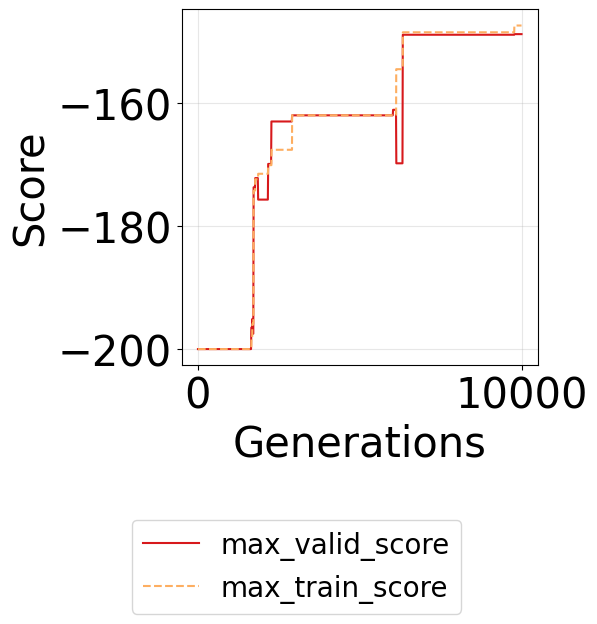

In [10]:
df_table_1P1_job = evolution_table_1P1.logs_to_df()
df_table_1P1_job["env_name"] = "MountainCar"
df_table_1P1_job["individual"] = "TableIndividual"

plot_lines(
    df_table_1P1_job,
    x_col="index_generation",
    y_col=["max_valid_score", "max_train_score"],
    xlabel="Generations",
    ylabel="Score",
    tick_labelsize=30,
    title_fontsize=36,
    title_pad=20,
    label_fontsize=30,
    legend_fontsize=20,
    save_file_path="notebook_figures/chapter2/_.pdf",
)

Same testing method as RL chapter

In [11]:
def test(individual:Individual, env_name, seed=0, animate=True):
    test_env = gym.make(env_name, render_mode='rgb_array')
    frames = []

    state, _ = test_env.reset(seed=seed)
    total_reward = 0

    representation = individual.getRepresentation()

    while True:
        action = individual.execute(representation, state)
        next_state, reward, terminated, truncated, _ = test_env.step(action)
        done = terminated or truncated

        state = next_state
        total_reward += reward
        frames.append(test_env.render())

        if done:
            break

    test_env.close()
    print('Final Score:', total_reward)

    if animate:
        fig = plt.figure(figsize=(8, 6))
        patch = plt.imshow(frames[0])
        plt.axis('off')

        def animate_frame(i):
            patch.set_data(frames[i])

        anim = animation.FuncAnimation(
            fig,
            animate_frame,
            frames=len(frames),
            interval=20,
        )

        plt.close(fig)
        display(HTML(anim.to_jshtml()))

In [12]:
test(evolution_table_1P1.best_individual, "MountainCar-v0", seed=4, animate=True)

Final Score: -163.0


Network Individual

In [13]:
class NetworkIndividual(Individual): 
    def __init__(self, nb_outputs, nb_inputs, is_continuous, nb_hidden_layers, nb_hidden_units, use_bias=True, genotype:bitarray = None): 
        self.nb_outputs = nb_outputs
        self.nb_inputs = nb_inputs
        self.is_continuous = is_continuous
        self.nb_hidden_layers = nb_hidden_layers
        self.nb_hidden_units = nb_hidden_units
        self.use_bias = True
        
        nb_weights = (nb_inputs + int(use_bias)) * nb_hidden_units
        
        for _ in range(nb_hidden_layers - 1):
            nb_weights += (nb_hidden_units + int(use_bias)) * nb_hidden_units

        nb_weights += (nb_hidden_units + int(use_bias)) * nb_outputs
        super().__init__(BinaryGenotype, nb_weights * 32, genotype)


    def bits_to_weight(self, bits):
        as_int = int(bits.to01(), 2)
        value = struct.unpack('!f', struct.pack('!I', as_int))[0]

        if not math.isfinite(value):
            value = 0.0   # or another fallback

        return value

    def getRepresentation(self): 

        weights = []
        idx = 0

        def decode_chunk(size):
            nonlocal idx
            vals = []
            for _ in range(size):
                chunk = self.genotype.bits[idx:idx+32]
                idx += 32
                vals.append(self.bits_to_weight(chunk))
            return np.array(vals, dtype=np.float32)

        # input → first hidden
        W = decode_chunk((self.nb_inputs + int(self.use_bias)) * self.nb_hidden_units)
        weights.append(W.reshape(self.nb_hidden_units, self.nb_inputs + int(self.use_bias)))

        # hidden layers
        for _ in range(self.nb_hidden_layers - 1):
            W = decode_chunk((self.nb_hidden_units + int(self.use_bias)) * self.nb_hidden_units)
            weights.append(W.reshape(self.nb_hidden_units, self.nb_hidden_units + int(self.use_bias)))

        # last layer
        W = decode_chunk((self.nb_hidden_units + int(self.use_bias)) * self.nb_outputs)
        weights.append(W.reshape(self.nb_outputs, self.nb_hidden_units + int(self.use_bias)))

        return weights

    def execute(self, representation, state):


        x = np.array(state, dtype=np.float32)

        # add bias
        if self.use_bias:
            x = np.append(x, 1.0)

        # forward pass
        for i, W in enumerate(representation):

            x = W @ x
            if i < len(representation) - 1:
                x = np.maximum(x, 0)  # ReLU

            # add bias except last layer
            if i < len(representation) - 1 and self.use_bias:
                x = np.append(x, 1.0)

        if self.is_continuous:
            return x
        else:
            return int(np.argmax(x))
    
    def copy(self): 
        return NetworkIndividual(self.nb_outputs, self.nb_inputs, self.is_continuous, self.nb_hidden_layers, self.nb_hidden_units, self.use_bias, genotype=self.genotype)

In [14]:
mountain_car = gym.make("MountainCar-v0")
args = 1, 64, True

evolution_network_1P1 = TwoMemberedEvolution(NetworkIndividual, args, mountain_car, mutation=BitFlipMutation(mutation_rate=0.1), seed=1)
evolution_network_1P1.train(10000, nb_train_episodes = 10, freq_validate=10)

Generation=0 --- Individuals=2 --- TRAIN - Max=-200.000 - Avg=-200.000 --- VALID Max=-200.000 - Avg=-200.000
Generation=100 --- Individuals=102 --- TRAIN - Max=-128.000 - Avg=-128.000 --- VALID Max=-118.500 - Avg=-118.500
Generation=200 --- Individuals=202 --- TRAIN - Max=-117.200 - Avg=-117.200 --- VALID Max=-107.200 - Avg=-107.200
Generation=300 --- Individuals=302 --- TRAIN - Max=-117.100 - Avg=-117.100 --- VALID Max=-107.100 - Avg=-107.100
Generation=400 --- Individuals=402 --- TRAIN - Max=-116.400 - Avg=-116.400 --- VALID Max=-106.900 - Avg=-106.900
Generation=500 --- Individuals=502 --- TRAIN - Max=-116.400 - Avg=-116.400 --- VALID Max=-106.900 - Avg=-106.900
Generation=600 --- Individuals=602 --- TRAIN - Max=-116.400 - Avg=-116.400 --- VALID Max=-106.900 - Avg=-106.900
Generation=700 --- Individuals=702 --- TRAIN - Max=-116.400 - Avg=-116.400 --- VALID Max=-106.900 - Avg=-106.900
Generation=800 --- Individuals=802 --- TRAIN - Max=-116.400 - Avg=-116.400 --- VALID Max=-106.900 - 

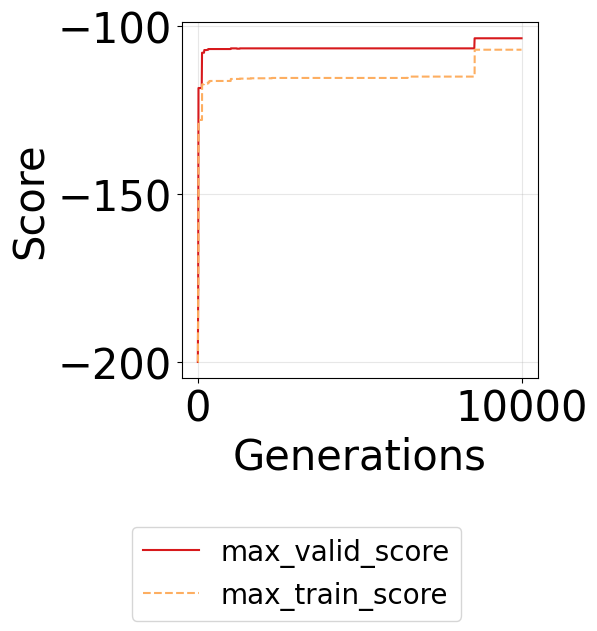

In [15]:
df_network_1P1_job = evolution_network_1P1.logs_to_df()
df_network_1P1_job["env_name"] = "MountainCar"
df_network_1P1_job["individual"] = "NetworkIndividual"

plot_lines(
    df_network_1P1_job,
    x_col="index_generation",
    y_col=["max_valid_score", "max_train_score"],
    xlabel="Generations",
    ylabel="Score",
    tick_labelsize=30,
    title_fontsize=36,
    title_pad=20,
    label_fontsize=30,
    legend_fontsize=20,
    save_file_path="notebook_figures/chapter2/_.pdf",
)

## 2. Multimembered Evolution Strategy for parameterized individuals

For multimembered Evolution Strategy, several class are now needed:
- Class for reproduction (-> crossover for instance)
- Selection methods
- variation methods (Although bitflip mutation is already used)
- replacement mechanism: choose between (µ+λ), (µ,λ) elitism...

#### Reproduction

In [16]:
class Reproduction(ABC):
    @abstractmethod
    def reproduce(self, individuals, nb_offsprings):
        pass

class Replication(Reproduction):
    def reproduce(self, individuals, nb_offsprings):
        return [individuals[random.randint(0, len(individuals) - 1)].copy() for _ in range(nb_offsprings)]

class NBinaryPointCrossover(Reproduction):
    def __init__(self, nb_points):
        self.nb_points = nb_points

    def nPointCrossover(self, parent0, parent1):
        if parent0.genotype.size != parent1.genotype.size:
            raise ValueError("Parents must have same size.")

        size = parent0.genotype.size
        n = min(self.nb_points, size - 1)

        cuts = np.sort(np.random.choice(np.arange(1, size), size=n, replace=False))

        child0 = bitarray()
        child1 = bitarray()

        start = 0
        swap = False

        for cut in np.append(cuts, size):

            if swap:
                child0.extend(parent1.genotype.bits[start:cut])
                child1.extend(parent0.genotype.bits[start:cut])
            else:
                child0.extend(parent0.genotype.bits[start:cut])
                child1.extend(parent1.genotype.bits[start:cut])

            swap = not swap
            start = cut

        c0 = parent0.copy()
        c1 = parent1.copy()

        c0.genotype.bits = child0
        c1.genotype.bits = child1

        return c0, c1

    def reproduce(self, individuals, nb_offsprings):
        
        offsprings = list()
        while(len(offsprings) < nb_offsprings):

            i0, i1 = random.sample(individuals, 2)

            if not isinstance(i0.genotype, BinaryGenotype) or not isinstance(i1.genotype, BinaryGenotype):
                raise ValueError('Binary crossover works only on binary genotypes')

            c0, c1 = self.nPointCrossover(i0, i1)
            offsprings.extend([c0, c1])
        
        if(len(offsprings) > nb_offsprings):
            offsprings = offsprings[:-1]
        return offsprings


Selection

In [17]:
class Selection(ABC):
    def __init__(self, allow_duplicates=True):
        self.allow_duplicates = allow_duplicates

    def select(self, nb_parents, individuals, fitnesses):
        pass

class RandomSelection(Selection):

    def select(self, nb_parents, individuals, fitnesses):
        if not self.allow_duplicates:
            return random.sample(individuals, min(nb_parents, len(individuals)))
        else:
            return random.choices(individuals, k=nb_parents)

class Tournament(Selection):

    def __init__(self, size_tournament=2, allow_duplicates=True):
        super().__init__(allow_duplicates)
        self.size_tournament = size_tournament

    def select(self, nb_parents, individuals, fitnesses):

        selected = []
        available = individuals.copy()

        nb_parents_used = nb_parents if self.allow_duplicates else min(nb_parents, len(individuals))

        for _ in range(nb_parents_used):

            tour = random.sample(available, min(self.size_tournament, len(available)))
            winner = max(tour, key=lambda x: fitnesses[x])
            selected.append(winner)

            if not self.allow_duplicates:
                available.remove(winner)
                if not available:
                    available = individuals.copy()

        return selected

class FitnessRoulette(Selection):

    def compute_weights(self, fitnesses, individuals):
        vals = [fitnesses[i] for i in individuals]
        m = max(vals)
        return [math.exp(v - m) for v in vals]

    def select(self, nb_parents, individuals, fitnesses):

        weights = self.compute_weights(fitnesses, individuals)

        if self.allow_duplicates:
            return random.choices(individuals, weights=weights, k=nb_parents)

        selected = []
        available = individuals.copy()
        w = weights.copy()

        for _ in range(min(nb_parents, len(individuals))):
            idx = random.choices(range(len(available)), weights=w, k=1)[0]
            selected.append(available[idx])
            available.pop(idx)
            w.pop(idx)

            if not available:
                available = individuals.copy()
                w = weights.copy()

        return selected


class RankedRoulette(FitnessRoulette):
    def compute_weights(self, fitnesses, individuals):
        ranked = sorted(individuals,
                        key=lambda x: (fitnesses[x], random.random()),
                        reverse=True)

        weights = [(i + 1) for i in range(len(ranked))][::-1]

        return weights

Replacement

In [18]:
class Replacement(ABC):
    def __init__(self, nb_parents, nb_offspring):
        self.nb_parents = nb_parents
        self.nb_offspring = nb_offspring

    def replace(self, parents, offsprings, population_scores, offspring_train_scores):
        pass

class MuPlusLambda(Replacement):
    def replace(self, parents, offsprings, population_scores, offspring_train_scores):
        comb = parents + offsprings
        scores = {**population_scores, **offspring_train_scores}
        mu = len(parents)
        pop = sorted(comb, key=lambda x: scores[x], reverse=True)[:mu]
        return pop, {x: scores[x] for x in pop}

class MuCommaLambda(Replacement):
    def __init__(self, nb_parents, nb_offspring, elits=0):
        super().__init__(nb_parents, nb_offspring)
        self.elits = elits

    def replace(self, parents, offsprings, population_scores, offspring_train_scores):
        scores = {**population_scores, **offspring_train_scores}
        
        elites = sorted(parents, key=lambda x: population_scores[x], reverse=True)[:self.elits]
        remaining = self.nb_parents - len(elites)
    
        rest = sorted(offsprings, key=lambda x: scores[x], reverse=True)[:remaining]
        pop = elites + rest
        return pop, {x: scores[x] for x in pop}


Multimembered strategy

In [19]:
class MultiMemberedEvolution(Evolution):
    def __init__(self, individual_class:classmethod, args_indiv:tuple, environment:gym.Env, 
                 replacement_=MuPlusLambda(100,100), selection_ = RandomSelection(), reproduction_ = Replication(), mutation = BitFlipMutation(0.01), 
                 seed=0):
        super().__init__(individual_class, args_indiv, environment, seed)
        self.mutation = mutation
        self.replacement_ = replacement_
        self.selection_ = selection_
        self.reproduction_ = reproduction_

    def initialization(self):
        return [self.individual_class(*self.args_indiv) for _ in range(self.replacement_.nb_parents)]

    def reproduction(self, individuals):
        return self.reproduction_.reproduce(individuals, self.replacement_.nb_offspring)
        
    def selection(self, individuals, fitnesses:dict):
        return self.selection_.select(self.replacement_.nb_offspring, individuals, fitnesses)

    def variation(self, individuals):
        for individual in individuals:
            self.mutation.mutate(individual)

    def replacement(self, parents, offsprings, population_scores, offspring_train_scores):
        return self.replacement_.replace(parents, offsprings, population_scores, offspring_train_scores)

In [20]:
args = 1, 64, True
evolution_network_multi = MultiMemberedEvolution(NetworkIndividual, args, mountain_car, 
                                               replacement_= MuPlusLambda(100, 100),
                                               selection_= FitnessRoulette(allow_duplicates=True),
                                               reproduction_= NBinaryPointCrossover(nb_points=3),
                                               mutation=BitFlipMutation(mutation_rate=0.1), seed=1)
evolution_network_multi.train(100, nb_train_episodes = 10, freq_validate=10)

Generation=0 --- Individuals=200 --- TRAIN - Max=-120.100 - Avg=-185.863 --- VALID Max=-118.500 - Avg=-185.547


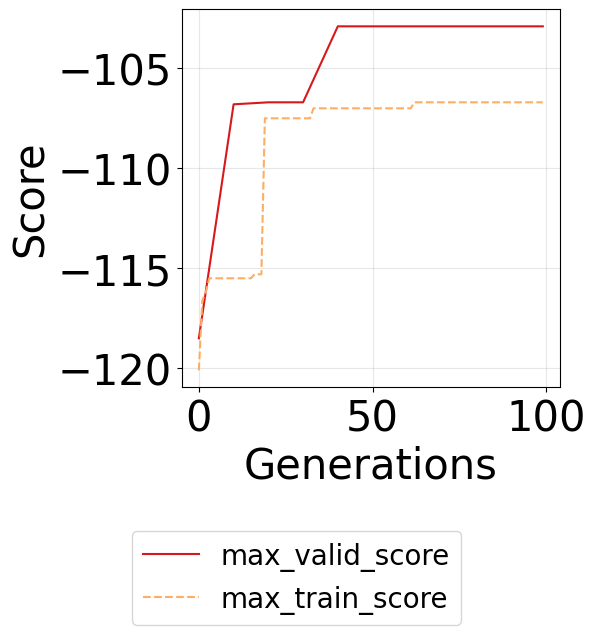

In [21]:
df_network_multi_job = evolution_network_multi.logs_to_df()
df_network_multi_job["env_name"] = "MountainCar"
df_network_multi_job["individual"] = "NetworkIndividual"

plot_lines(
    df_network_multi_job, x_col="index_generation", y_col=["max_valid_score", "max_train_score"], xlabel="Generations", ylabel="Score", tick_labelsize=30, title_fontsize=36, title_pad=20, label_fontsize=30, legend_fontsize=20, save_file_path="notebook_figures/chapter2/_.pdf",
)

## 3. Genetic Programming individuals with binary genotype

Create GP classes

GP Classes will use node representation, encoded as binary for now

In [22]:
class Node(ABC):
    """Abstract base class for GP nodes - all GP representations use nodes"""
    def __init__(self):
        pass

    @abstractmethod
    def execute(self, state, instruction_set):
        pass

    @abstractmethod
    def print(self, instruction_names, nb_inputs):
        pass

Tree-based GP

In [23]:
class TGPNodeExec(Node):
    def __init__(self, index):
        super().__init__()
        self.index = index
        self.children = list()
    
    def execute(self, state, instruction_set):
        if len(self.children) != 2:
            return state[self.index % len(state)]
        i0 = self.children[0].execute(state, instruction_set) 
        i1 = self.children[1].execute(state, instruction_set)
        return instruction_set[self.index % len(instruction_set)](i0, i1)

    def print(self, instruction_names, nb_inputs):
        if len(self.children) != 2:
            return f"S[{self.index % nb_inputs}]"
        return (
            f"{instruction_names[self.index % len(instruction_names)]}"
            f"({self.children[0].print(instruction_names, nb_inputs)}, {self.children[1].print(instruction_names, nb_inputs)})"
        )



class TreeBasedGPIndividual(Individual): 
    def __init__(self, nb_outputs:int, nb_inputs:int, is_continuous, nb_nodes:int, instruction_set, genotype:Genotype = None): 
        self.nb_outputs = nb_outputs
        self.nb_inputs = nb_inputs
        self.is_continuous = is_continuous

        self.nb_nodes = nb_nodes
        self.instruction_set = instruction_set

        self.bit_length_instruction_set = (len(instruction_set) - 1).bit_length()
        self.bit_length_input_index = (nb_inputs -1).bit_length()

        self.nb_bits_per_nodes = max(self.bit_length_input_index, self.bit_length_instruction_set) + 1


        super().__init__(BinaryGenotype, self.nb_bits_per_nodes * nb_nodes, genotype)

    def getRepresentation(self):

        root_node = None
        current_parents = []

        for idx_node in range(self.nb_nodes):

            sub_bit_array = self.genotype.bits[
                idx_node*self.nb_bits_per_nodes:
                (idx_node+1)*self.nb_bits_per_nodes
            ]


            is_terminal = not int(sub_bit_array[0:1].to01(), 2)
            index = int(sub_bit_array[1:].to01(), 2)

            node = TGPNodeExec(index)

            if idx_node == 0:
                root_node = node

            elif current_parents:
                current_parents[-1].children.append(node)

                while current_parents and len(current_parents[-1].children) == 2:
                    current_parents.pop()
            else:
                break

            if not is_terminal:
                current_parents.append(node)

        return root_node


    def execute(self, representation, state):
        output = representation.execute(state, self.instruction_set)
        if self.is_continuous:
            return output
        else:
            return int(np.clip(np.round(output), 0, self.nb_outputs-1))

    def print(self, instruction_names):
        representation = self.getRepresentation()
        print(representation.print(instruction_names, self.nb_inputs))
        
    
    def copy(self): 
        return TreeBasedGPIndividual(self.nb_outputs, self.nb_inputs, self.is_continuous, self.nb_nodes, self.instruction_set, genotype=self.genotype)

Linear GP

In [24]:
class LinearGPIndividual(Individual): 
    def __init__(self, nb_outputs:int, nb_inputs:int, is_continuous, nb_lines:int, nb_registers:int, instruction_set, genotype:Genotype = None): 
        self.nb_outputs = nb_outputs
        self.nb_inputs = nb_inputs
        self.is_continuous = is_continuous

        self.nb_lines = nb_lines
        self.nb_registers = nb_registers
        self.instruction_set = instruction_set

        self.bit_length_instruction_set = (len(instruction_set) - 1).bit_length()
        self.bit_length_output_line = (nb_registers-1).bit_length()
        self.bit_length_input_type = 1

        self.bit_length_state = (nb_inputs-1).bit_length()
        self.bit_length_input_index = max(self.bit_length_output_line, self.bit_length_state)


        self.bit_start_instruction_set = 0
        self.bit_start_output_line = self.bit_start_instruction_set + self.bit_length_instruction_set
        self.bit_start_input_0_type = self.bit_start_output_line + self.bit_length_output_line
        self.bit_start_input_0_index = self.bit_start_input_0_type + self.bit_length_input_type
        self.bit_start_input_1_type = self.bit_start_input_0_index + self.bit_length_input_index
        self.bit_start_input_1_index = self.bit_start_input_1_type + self.bit_length_input_type

        self.nb_bits_per_lines = self.bit_start_input_1_index + self.bit_length_input_index


        super().__init__(BinaryGenotype, self.nb_bits_per_lines * nb_lines, genotype)


    def remove_introns(self, representation: list):
        # First nb_outputs registers are outputs
        useful_registers = set(range(self.nb_outputs))

        for idx_line in range(len(representation)-1, -1, -1):
            line = representation[idx_line]
            if line[1] in useful_registers:
                useful_registers.remove(line[1])
                if line[2] == 1:
                    useful_registers.add(line[3])

                if line[4] == 1:
                    useful_registers.add(line[5])

            else:
                representation.pop(idx_line)


    def getRepresentation(self):

        representation = []
        for idx_line in range(self.nb_lines):

            sub_bit_array = self.genotype.bits[idx_line*self.nb_bits_per_lines:(idx_line+1)*self.nb_bits_per_lines]
            idx_instruction = int(sub_bit_array[self.bit_start_instruction_set:self.bit_start_instruction_set + self.bit_length_instruction_set].to01(), 2)

            idx_output = int(sub_bit_array[self.bit_start_output_line:self.bit_start_output_line + self.bit_length_output_line].to01(), 2)
            
            idx_type_input_0 = int(sub_bit_array[self.bit_start_input_0_type:self.bit_start_input_0_type + self.bit_length_input_type].to01(), 2)
            idx_index_input_0 = int(sub_bit_array[self.bit_start_input_0_index:self.bit_start_input_0_index + self.bit_length_input_index].to01(), 2)

            idx_type_input_1 = int(sub_bit_array[self.bit_start_input_1_type:self.bit_start_input_1_type + self.bit_length_input_type].to01(), 2)
            idx_index_input_1 = int(sub_bit_array[self.bit_start_input_1_index:self.bit_start_input_1_index + self.bit_length_input_index].to01(), 2)


            idx_instruction %= len(self.instruction_set)
            idx_output %= self.nb_registers
            idx_index_input_0 %=  self.nb_registers if idx_type_input_0 else self.nb_inputs
            idx_index_input_1 %=  self.nb_registers if idx_type_input_1 else self.nb_inputs

            representation.append(
                [idx_instruction, 
                 idx_output, 
                 idx_type_input_0, 
                 idx_index_input_0, 
                 idx_type_input_1, 
                 idx_index_input_1
                ])

         
        self.remove_introns(representation)

        return representation


    def execute(self, representation, state):
        registers = np.zeros(self.nb_registers)

        for line in representation:
            # line format: [instruction, output_register, type0, idx0, type1, idx1]
            input_idx_0 = min(line[3], self.nb_inputs - 1) if line[2] == 0 else min(line[3], self.nb_registers - 1)
            input_idx_1 = min(line[5], self.nb_inputs - 1) if line[4] == 0 else min(line[5], self.nb_registers - 1)
            
            input_0 = state[input_idx_0] if line[2] == 0 else registers[input_idx_0]
            input_1 = state[input_idx_1] if line[4] == 0 else registers[input_idx_1] 
            registers[line[1]] = self.instruction_set[line[0]](input_0, input_1)
        
        # Clamp output to valid action range
        outputs = registers[:self.nb_outputs]
        if self.is_continuous:
            return outputs
        else:
            return np.argmax(outputs)
        

    def print(self, instruction_names):
        lines = self.getRepresentation()
        for line in lines:
            input_0 = f"S[{line[3]}]" if line[2] == 0 else f"R[{line[3]}]"
            input_1 = f"S[{line[5]}]" if line[4] == 0 else f"R[{line[5]}]"
            output = f"R[{line[1]}]"
            instr = instruction_names[line[0]]

            print(output + " = " + instr + "(" + input_0 + ", "+ input_1 + ")")
        
    
    def copy(self): 
        return LinearGPIndividual(self.nb_outputs, self.nb_inputs, self.is_continuous, self.nb_lines, self.nb_registers, self.instruction_set, genotype=self.genotype)

Cartesian GP

In [25]:
class CartesianGPIndividual(Individual): 
    def __init__(self, nb_outputs:int, nb_inputs:int, is_continuous, nb_layer:int, nb_node_layer:int, instruction_set, genotype:Genotype = None): 
        self.nb_outputs = nb_outputs
        self.nb_inputs = nb_inputs
        self.is_continuous = is_continuous

        self.nb_layer = nb_layer
        self.nb_node_layer = nb_node_layer
        self.instruction_set = instruction_set

        
        self.bit_length_instruction_set = (len(instruction_set) - 1).bit_length()

        self.nb_inputs_layers = []
        self.bits_length_input_layers = []
        self.bits_length_node_layers = []
        self.bits_length_layers = []
        self.nb_bits_intermediate_layers = 0
        for layer in range(nb_layer):
            nb_inputs_layer = self.nb_inputs + layer * self.nb_node_layer
            bits_length_input_layer = (nb_inputs_layer-1).bit_length()
            bits_length_node_layer = bits_length_input_layer * 2 + self.bit_length_instruction_set
            bits_length_layer = bits_length_node_layer * self.nb_node_layer

            self.nb_inputs_layers.append(nb_inputs_layer)
            self.bits_length_input_layers.append(bits_length_input_layer)
            self.bits_length_node_layers.append(bits_length_node_layer)
            self.bits_length_layers.append(bits_length_layer)
            self.nb_bits_intermediate_layers += bits_length_layer
        
        self.nb_input_at_output = self.nb_inputs + nb_layer * self.nb_node_layer
        self.nb_bits_output_node = (self.nb_input_at_output - 1).bit_length()
        self.nb_bits_output_layer = self.nb_outputs * self.nb_bits_output_node


        super().__init__(BinaryGenotype, self.nb_bits_intermediate_layers + self.nb_bits_output_layer, genotype)

    def remove_introns(self, representation):

        useful = set()

        # outputs
        for out in representation[-1]:
            if out is None:
                continue
            if out[0] != 0:
                useful.add((out[0]-1, out[1]))

        # backward closure
        changed = True
        while changed:
            changed = False

            for l in range(self.nb_layer):
                for i, node in enumerate(representation[l]):

                    if node is None or (l, i) not in useful:
                        continue

                    for inp_l, inp_n in [(node[1], node[2]), (node[3], node[4])]:
                        if inp_l != 0 and (inp_l-1, inp_n) not in useful:
                            useful.add((inp_l-1, inp_n))
                            changed = True

        # prune
        for l in range(self.nb_layer):
            for i in range(self.nb_node_layer):
                if (l, i) not in useful:
                    representation[l][i] = None

    def getRepresentation(self):

        representation = []
        offset = 0
        for idx_layer in range(self.nb_layer):
            
            nb_inputs = self.nb_inputs_layers[idx_layer]
            bits_length_input = self.bits_length_input_layers[idx_layer]
            bits_length_node = self.bits_length_node_layers[idx_layer]
            bits_length_layer = self.bits_length_layers[idx_layer]


            sub_bit_array = self.genotype.bits[offset:offset + bits_length_layer]
            offset += bits_length_layer
            layer = []

            for idx_node in range(self.nb_node_layer):

                node_bit_array =  sub_bit_array[idx_node*bits_length_node:(idx_node+1)*bits_length_node]

                idx_instruction = int(node_bit_array[0:self.bit_length_instruction_set].to01(), 2)
                idx_index_input_0 = int(node_bit_array[self.bit_length_instruction_set:self.bit_length_instruction_set + bits_length_input].to01(), 2)
                idx_index_input_1 = int(node_bit_array[self.bit_length_instruction_set+bits_length_input:self.bit_length_instruction_set + bits_length_input*2].to01(), 2)


                idx_instruction %= len(self.instruction_set)
                idx_index_input_0 %= nb_inputs
                idx_index_input_1 %= nb_inputs

                if idx_index_input_0 < self.nb_inputs:
                    input_layer_index_0 = 0
                    input_node_index_0 = idx_index_input_0
                else:
                    idx_index_input_0 -= self.nb_inputs
                    input_layer_index_0 = (idx_index_input_0 // self.nb_node_layer) + 1
                    input_node_index_0 = idx_index_input_0 % self.nb_node_layer

                if idx_index_input_1 < self.nb_inputs:
                    input_layer_index_1 = 0
                    input_node_index_1 = idx_index_input_1
                else:
                    idx_index_input_1 -= self.nb_inputs
                    input_layer_index_1 = (idx_index_input_1 // self.nb_node_layer) + 1
                    input_node_index_1 = idx_index_input_1 % self.nb_node_layer

                layer.append([idx_instruction, input_layer_index_0, input_node_index_0, input_layer_index_1, input_node_index_1])
            representation.append(layer)


        output_layer = []
        output_sub_array = self.genotype.bits[-self.nb_bits_output_layer:]

        for i in range(self.nb_outputs):

            start = i * self.nb_bits_output_node
            end = start + self.nb_bits_output_node

            value = int(output_sub_array[start:end].to01(), 2)

            value %= self.nb_input_at_output

            if value < self.nb_inputs:
                output_layer_index = 0
                output_node_index = value
            else:
                value -= self.nb_inputs
                output_layer_index = (value // self.nb_node_layer) + 1
                output_node_index = value % self.nb_node_layer

            output_layer.append([output_layer_index, output_node_index])

        

        representation.append(output_layer)
        self.remove_introns(representation)
        return representation
    


    def execute(self, representation, state):
        nodes_outputs = np.zeros((self.nb_layer, self.nb_node_layer))

        for idx_layer in range(self.nb_layer):
            for idx_node in range(self.nb_node_layer):
                if representation[idx_layer][idx_node] is None:
                    continue
                node = representation[idx_layer][idx_node]
                
                if(node[1] == 0):
                    input_0 = state[node[2]]
                else:
                    input_0 = nodes_outputs[node[1]-1][node[2]]

                if(node[3] == 0):
                    input_1 = state[node[4]]
                else:
                    input_1 = nodes_outputs[node[3]-1][node[4]]
                nodes_outputs[idx_layer][idx_node] = self.instruction_set[node[0]](input_0, input_1)

        
        outputs = []

        for output_node in representation[-1]:

            if output_node[0] == 0:
                value = state[output_node[1]]
            else:
                value = nodes_outputs[output_node[0]-1][output_node[1]]

            outputs.append(value)

        outputs = np.array(outputs)

        if self.is_continuous:
            return outputs
        else:
            return np.argmax(outputs)

    def print(self, instruction_names):
        rep = self.getRepresentation()

        for layer_idx in range(self.nb_layer):
            print(f"Layer {layer_idx}")

            for node_idx in range(self.nb_node_layer):
                if rep[layer_idx][node_idx] is None:
                    continue

                node = rep[layer_idx][node_idx]

                instr = instruction_names[node[0]]

                if node[1] == 0:
                    in0 = f"S[{node[2]}]"
                else:
                    in0 = f"N[{node[1]-1},{node[2]}]"

                if node[3] == 0:
                    in1 = f"S[{node[4]}]"
                else:
                    in1 = f"N[{node[3]-1},{node[4]}]"

                print(
                    f"N[{layer_idx},{node_idx}] = "
                    f"{instr}({in0}, {in1})"
                )

        for i, output in enumerate(rep[-1]):

            if output[0] == 0:
                out = f"S[{output[1]}]"
            else:
                out = f"N[{output[0]-1},{output[1]}]"

            print(f"OUTPUT[{i}] = {out}")
        
    
    def copy(self): 
        return CartesianGPIndividual(self.nb_outputs, self.nb_inputs, self.is_continuous, self.nb_layer, self.nb_node_layer, self.instruction_set, genotype=self.genotype)

Instructions

In [26]:
# Function set for symbolic regression
# CRITICAL FIX: Changed ^ to ** (Python exponentiation operator)
INSTRUCTION_SET = [
    lambda x, y: x + y,      # Addition
    lambda x, y: x - y,      # Subtraction  
    lambda x, y: x * y,      # Multiplication
    lambda x, y: 1.0 if abs(y) < 1e-10 else x / y, # safe division
    lambda x, y: x if x > y else y,
    lambda x, y: np.sin(x),
    lambda x, y: np.log(abs(x) + 1e-10)
]

INSTRUCTION_NAMES = ['+', '-', '*', '/', 'max', "sin",'log']

In [27]:
args = 7, INSTRUCTION_SET

mountain_car = gym.make("MountainCar-v0")

evolution_TGP_multi = MultiMemberedEvolution(TreeBasedGPIndividual, args, mountain_car, 
                                               replacement_= MuPlusLambda(100, 100),
                                               selection_= RankedRoulette(),
                                               reproduction_= NBinaryPointCrossover(nb_points=3),
                                               mutation=BitFlipMutation(mutation_rate=0.1), seed=0)
evolution_TGP_multi.train(100, nb_train_episodes = 10, freq_validate=10)


Generation=0 --- Individuals=200 --- TRAIN - Max=-160.200 - Avg=-199.602 --- VALID Max=-160.500 - Avg=-199.605


In [38]:
args = 20, 8, INSTRUCTION_SET
lunar = gym.make("LunarLander-v3")


evolution_LGP_multi = MultiMemberedEvolution(LinearGPIndividual, args, mountain_car, 
                                               replacement_= MuPlusLambda(100, 100),
                                               selection_= Tournament(size_tournament=2),
                                               reproduction_= Replication(),
                                               mutation=BitFlipMutation(mutation_rate=0.01), seed=0)
evolution_LGP_multi.train(100, nb_train_episodes = 5, freq_validate=10, determinist=False)

Generation=0 --- Individuals=200 --- TRAIN - Max=-133.200 - Avg=-188.422 --- VALID Max=-118.500 - Avg=-188.023


In [39]:
args = 2, 5, INSTRUCTION_SET
evolution_CGP_multi = MultiMemberedEvolution(CartesianGPIndividual, args, mountain_car, 
                                               replacement_= MuPlusLambda(100, 100),
                                               selection_= Tournament(size_tournament=2),
                                               reproduction_= Replication(),
                                               mutation=BitFlipMutation(mutation_rate=0.1), seed=0)
evolution_CGP_multi.train(100, nb_train_episodes = 5, freq_validate=10)



Generation=0 --- Individuals=200 --- TRAIN - Max=-155.000 - Avg=-196.910 --- VALID Max=-156.800 - Avg=-197.102


In [40]:

evolution_CGP_multi.population[2].print(INSTRUCTION_NAMES)

Layer 0
N[0,0] = *(S[1], S[1])
N[0,3] = sin(S[1], S[1])
Layer 1
N[1,0] = /(N[0,0], N[0,3])
OUTPUT[0] = S[1]
OUTPUT[1] = S[1]
OUTPUT[2] = N[1,0]


TGP


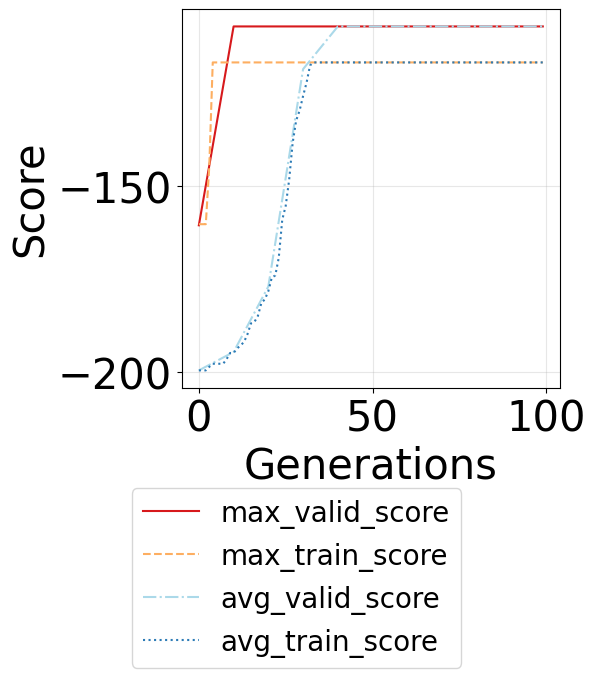

LGP


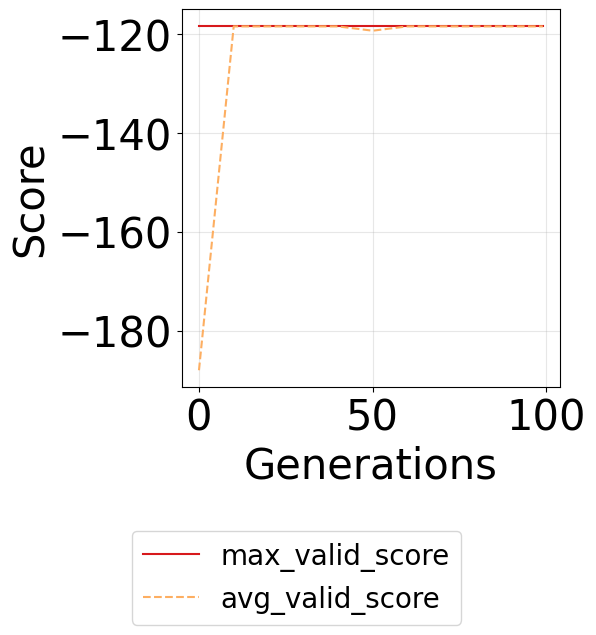

CGP


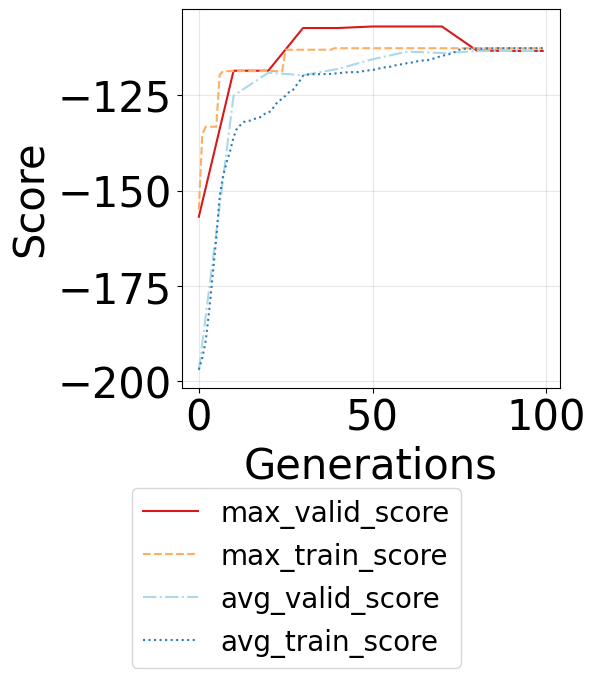

In [41]:
df_TGP_multi_job = evolution_TGP_multi.logs_to_df()

df_LGP_multi_job = evolution_LGP_multi.logs_to_df()

df_CGP_multi_job = evolution_CGP_multi.logs_to_df()

print("TGP")
plot_lines(
    df_TGP_multi_job, x_col="index_generation", y_col=["max_valid_score", "max_train_score", "avg_valid_score", "avg_train_score"], xlabel="Generations", ylabel="Score", tick_labelsize=30, title_fontsize=36, title_pad=20, label_fontsize=30, legend_fontsize=20, save_file_path="notebook_figures/chapter2/_.pdf",
)
print("LGP")
plot_lines(
    df_LGP_multi_job, x_col="index_generation", y_col=["max_valid_score", "avg_valid_score"], xlabel="Generations", ylabel="Score", tick_labelsize=30, title_fontsize=36, title_pad=20, label_fontsize=30, legend_fontsize=20, save_file_path="notebook_figures/chapter2/_.pdf",
)
print("CGP")
plot_lines(
    df_CGP_multi_job, x_col="index_generation", y_col=["max_valid_score", "max_train_score", "avg_valid_score", "avg_train_score"], xlabel="Generations", ylabel="Score", tick_labelsize=30, title_fontsize=36, title_pad=20, label_fontsize=30, legend_fontsize=20, save_file_path="notebook_figures/chapter2/_.pdf",
)

In [42]:
evolution_TGP_multi.best_individual.print(INSTRUCTION_NAMES)

/(/(S[0], S[0]), S[1])


In [43]:
evolution_LGP_multi.best_individual.print(INSTRUCTION_NAMES)

R[4] = *(S[0], S[0])
R[1] = log(S[1], R[4])
R[2] = +(S[1], S[1])
R[0] = *(S[1], S[1])


In [44]:
evolution_CGP_multi.best_individual.print(INSTRUCTION_NAMES)

Layer 0
N[0,0] = *(S[1], S[1])
N[0,1] = sin(S[1], S[1])
Layer 1
N[1,0] = /(N[0,0], S[1])
OUTPUT[0] = N[0,1]
OUTPUT[1] = N[0,1]
OUTPUT[2] = N[1,0]


## 4. Launching multiple training and draw comparisons

In [ ]:
from joblib import Parallel, delayed
from itertools import product
import copy



In [ ]:
def run_experiment(args):
    (params, nb_gen, nb_train_episodes, freq_validate, nb_valid_episodes) = args


    env = gym.make(params["env_name"])

    p = params["rep_params"]
    if params["rep_name"] == "Table":
        upper_bounds = np.clip(env.observation_space.high, -10, 10)
        lower_bounds = np.clip(env.observation_space.low, -10, 10)
        args = upper_bounds, lower_bounds, p["nb_bits_values"], p["nb_bins"]
        rep = TableIndividual
    if params["rep_name"] == "Network":
        args = p["hidden_layer"], p["hidden_size"], p["bias"]
        rep = NetworkIndividual
    if params["rep_name"] == "TGP":
        args = p["nb_nodes"], INSTRUCTION_SET
        rep = TreeBasedGPIndividual
        pass
    if params["rep_name"] == "LGP":
        args = p["nb_lines"], p["nb_registers"], INSTRUCTION_SET
        rep = LinearGPIndividual
        pass
    if params["rep_name"] == "CGP":
        args = p["nb_layers"], p["nb_nodes_layer"], INSTRUCTION_SET
        rep = CartesianGPIndividual
        pass

    evo_rules_params = params["evolution"]
    if evo_rules_params["replacement"] == "(mu+lambda)":
        replacement = MuPlusLambda(evo_rules_params["mu"], evo_rules_params["lambda"])
    else:
        replacement = MuCommaLambda(evo_rules_params["mu"], evo_rules_params["lambda"], evo_rules_params["elits"])
    
    if evo_rules_params["selection"] == "random":
        selection = RandomSelection(allow_duplicates=evo_rules_params["selection_dupplicates"])
    elif evo_rules_params["selection"] == "tournament":
        selection = Tournament(evo_rules_params["size_tournament"], evo_rules_params["selection_dupplicates"])
    elif evo_rules_params["selection"] == "fitnessRoulette":
        selection = FitnessRoulette(evo_rules_params["selection_dupplicates"])
    elif evo_rules_params["selection"] == "rankedRoulette":
        selection = RankedRoulette(evo_rules_params["selection_dupplicates"])

    if evo_rules_params["reproduction"] == "replication":
        reproduction_ = Replication()
    else:
        reproduction_ = NBinaryPointCrossover(evo_rules_params["NbPointCross"])
    
    mutation = BitFlipMutation(evo_rules_params["mutation_rate"])

    if params["env_name"] == "LunarLander-v3":
        nb_gen = nb_gen * 3

    job = MultiMemberedEvolution(rep, args, env, replacement, selection, reproduction_, mutation, params["seed"])
    job.train(nb_gen, nb_train_episodes=nb_train_episodes, verbose=0, freq_validate=freq_validate, nb_valid_episodes=nb_valid_episodes, smooth_train = 100, smooth_valid = 10, determinist=False)

    env.close()


    return {
        "seed": params["seed"],
        "population": job.population,
        "best": job.best_individual,
        "rep_name": params["rep_name"],
        "rep_params": params["rep_params"],
        "env_name": params["env_name"],
        "evolution": params["evolution"],
        "logs": job.logs_to_df(),
    }

In [ ]:
def create_tasks(tasks, results, base_params, variations,
                 nb_gen=100,
                 nb_train_episodes=10,
                 freq_validate=10,
                 nb_valid_episodes=10):

    def make_signature(params):
        return (
            params["env_name"],
            params["rep_name"],
            params["seed"],
            tuple(sorted(params["rep_params"].items())),
            tuple(sorted(params["evolution"].items()))
        )

    # build set of already-run configs
    done = set()
    for r in results:
        params = {
            "env_name": r["env_name"],
            "rep_name": r["rep_name"],
            "seed": r["seed"],
            "rep_params": r["rep_params"],
            "evolution": r["evolution"]
        }
        done.add(make_signature(params))

    for params, *_ in tasks:
        done.add(make_signature(params))

    envs = variations["env_name"]
    reps = variations["rep_name"]
    seeds = variations["seed"]
    rep_grids = variations.get("rep_grids", {})
    evo_grid = variations.get("evo_grid", {})

    nb_tasks_added = 0
    nb_tasks_skipped = 0

    for env in envs:
        for rep in reps:

            rep_grid = rep_grids.get(rep, {})

            rep_keys = list(rep_grid.keys())
            rep_values = list(rep_grid.values())
            rep_combos = list(product(*rep_values)) if rep_values else [()]

            evo_keys = list(evo_grid.keys())
            evo_values = list(evo_grid.values())
            evo_combos = list(product(*evo_values)) if evo_values else [()]
            for rep_combo in rep_combos:
                rep_overrides = dict(zip(rep_keys, rep_combo))

                for evo_combo in evo_combos:
                    evo_overrides = dict(zip(evo_keys, evo_combo))

                    for seed in seeds:
                        params = copy.deepcopy(base_params)

                        params["env_name"] = env
                        params["rep_name"] = rep
                        params["seed"] = seed

                        # representation params
                        params["rep_params"] = copy.deepcopy(params[rep])
                        params["rep_params"].update(rep_overrides)

                        # evolution params
                        params["evolution"] = copy.deepcopy(params.get("evolution", {}))
                        params["evolution"].update(evo_overrides)

                        sig = make_signature(params)

                        if sig in done:
                            nb_tasks_skipped += 1
                            continue

                        tasks.append(
                            (params, nb_gen, nb_train_episodes, freq_validate, nb_valid_episodes)
                        )

                        nb_tasks_added += 1
                        done.add(sig)
    print(f"Creation of task completed.\nAddition of {nb_tasks_added} tasks for a total of {len(tasks)}\nSkipped {nb_tasks_skipped} because dupplicated")

In [ ]:
def init_worker():
    warnings.filterwarnings("ignore", message="Signature .* for <class 'numpy.longdouble'>")

def train_on_tasks(results, tasks, nb_jobs):
    print(f"Launching {len(tasks)} experiments")

    outputs = Parallel(
        n_jobs=nb_jobs,
        backend="loky",
        verbose=10,
        #initializer=init_worker,  # Apply the filter to each worker
    )(
        delayed(run_experiment)(task)
        for task in tasks
    )

    results.extend(outputs)
    tasks.clear()

In [ ]:
def select_runs(results, env_name, rep_name, rep_params=None, evo_params=None):
    runs = results.values() if isinstance(results, dict) else results

    out = []
    for r in runs:
        if r["env_name"] != env_name:
            continue

        if r["rep_name"] != rep_name:
            continue

        if rep_params is not None:
            if not all(
                r["rep_params"].get(k) == v
                for k, v in rep_params.items()
            ):
                continue

        if rep_params is not None:
            if not all(
                r["rep_params"].get(k) == v
                for k, v in rep_params.items()
            ):
                continue
        if evo_params is not None:
            if not all(
                r["evolution"].get(k) == v
                for k, v in evo_params.items()
            ):
                continue

        out.append(r)

    return out


def aggregate_metric_over_seeds(runs, metric, x_col="index_generation"):
    frames = []


    for r in runs:
        logs = r.get("logs")
        if logs is None or metric not in logs.columns or x_col not in logs.columns:
            continue

        df = logs[[x_col, metric]].copy()
        df = df.dropna(subset=[metric])
        if df.empty:
            continue

        # In case the same episode appears multiple times in a run, keep one value per x_col
        df = df.groupby(x_col, as_index=False)[metric].mean()
        df["seed"] = r.get("seed", None)
        frames.append(df)

    if not frames:
        return pd.DataFrame(columns=[x_col, "mean", "std", "min", "max", "count"])

    all_df = pd.concat(frames, ignore_index=True)

    agg = (
        all_df.groupby(x_col)[metric]
        .agg(mean="mean", std="std", min="min", max="max", count="count")
        .reset_index()
        .sort_values(x_col)
    )

    return agg


def plot_configurations(
    results,
    env_name,
    configs,
    figsize=(6, 6),
    xlabel="Generation",
    input = "index_generation",
    ylabel=None,
    title=None,
    tick_labelsize=30,
    title_fontsize=36,
    title_pad=20,
    label_fontsize=30,
    legend_fontsize=20,
    save_file_path=None,
    show_min_max=True,
    n_col_legend=None,
    y_margin=0.3,
    x_ticks = None
):

    if isinstance(env_name, str):
        env_names = [env_name]
    else:
        env_names = env_name

    fig, axes = plt.subplots(
        ncols=len(env_names),
        figsize=(figsize[0] * len(env_names), figsize[1]),
        squeeze=False,
    )

    axes = axes.ravel()

    all_handles = []
    all_labels = []

    for env_index, (ax, env) in enumerate(zip(axes, env_names)):
        all_means = []
        all_mins = []
        all_maxs = []



        for line_index, cfg in enumerate(configs):

            runs = select_runs(
                results,
                env_name=env,
                rep_name=cfg["rep_name"],
                rep_params=cfg.get("rep_params", {}),
                evo_params=cfg.get("evolution", {}),
            )

            metric="max_valid_score"
            if "metric" in cfg:
                metric=cfg["metric"]

            agg = aggregate_metric_over_seeds(
                runs,
                metric,
                x_col=input
            )

            if agg.empty:
                continue

            if env == "LunarLander-v3":
                ax.plot(agg[input], np.ones(agg[input].count())* 200,color="black", linewidth=0.5, zorder=0)

            line, = ax.plot(
                agg[input],
                agg["mean"],
                label=cfg["label"],
                linestyle=line_styles[line_index],
                color=line_colors[line_index],
            )


            if cfg["label"] not in all_labels:
                all_handles.append(line)
                all_labels.append(cfg["label"])

            if show_min_max:
                std = agg["std"].fillna(0)

                ax.fill_between(
                    agg[input],
                    agg["min"],
                    agg["max"],
                    alpha=0.1,
                    color=line_colors[line_index],
                )
            all_means.extend(agg["mean"].tolist())
            all_mins.extend(agg["min"].tolist())
            all_maxs.extend(agg["max"].tolist())

        if all_means:
            mean_min = min(all_means)
            mean_max = max(all_means)
            mean_range = mean_max - mean_min
            margin = mean_range * y_margin

            new_min = max(min(all_mins), mean_min - margin)
            new_max = min(max(all_maxs), mean_max + margin)
            ax.set_ylim(new_min - margin*0.1, new_max + margin*0.1)


        if title is not None:
            ax.set_title(
                title[env_index],
                fontsize=title_fontsize,
                pad=title_pad,
            )

        ax.set_xlabel(
            xlabel,
            fontsize=label_fontsize,
        )

        if x_ticks is not None:
            ax.set_xticks(
                x_ticks[env_index]
            )

        if env_index == 0 and ylabel is not None:
            ax.set_ylabel(
                ylabel,
                fontsize=label_fontsize,
            )

        ax.grid(True, alpha=0.3)

        ax.tick_params(
            axis="both",
            which="major",
            labelsize=tick_labelsize,
        )

        ax.set_box_aspect(1)

    fig.legend(
        all_handles,
        all_labels,
        frameon=True,
        fontsize=legend_fontsize,
        loc="center",
        ncol=len(configs) if n_col_legend is None else n_col_legend,
        bbox_to_anchor=(0.5, -0.05),
    )

    plt.tight_layout()

    if save_file_path is not None:
        plt.savefig(
            save_file_path,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

In [ ]:
base_params = {
    "seed": 0,
    "env_name": "MountainCar-v0",
    "rep_name": "Network",

    "Table": {
        "nb_bits_values":8,
        "nb_bins":20
    },
    "Network": {
        "hidden_layer": 2,
        "hidden_size": 64,
        "bias":True
    },
    "TGP": {
        "nb_nodes":25
    },
    "LGP": {
        "nb_lines":16,
        "nb_registers":8
    },
    "CGP": {
        "nb_layers":3,
        "nb_nodes_layer":5
    },

    "evolution":{
        "replacement":"(mu+lambda)",
        "mu":10,
        "lambda":10,
        "elits":0,
        "selection":"random",
        "selection_dupplicates":True,
        "size_tournament":2,
        "reproduction":"replication",
        "NbPointCross":1,
        "mutation_rate":0.01
    }
}



In [ ]:
results = []
tasks = []
nb_seeds = 5
#nb_gen = 5
nb_episodes = 5

In [ ]:
variations = {
    "seed": [i for i in range(nb_seeds)],
    "env_name": ["LunarLander-v3","MountainCar-v0"],
    "rep_name": ["Network"],

    "rep_grids": {
        "Network": {
            "hidden_size": [64],
            "hidden_layer": [1],
        },
    },
    "evo_grid":{
        "selection":["random"],
        "mu":[1],
        "lambda":[1]
    }
}

create_tasks(tasks, results, base_params, variations, nb_train_episodes=nb_episodes, nb_gen=10000)

variations["evo_grid"]["mu"] = [1]
variations["evo_grid"]["lambda"] = [10]
create_tasks(tasks, results, base_params, variations, nb_train_episodes=nb_episodes, nb_gen=1000)

variations["evo_grid"]["mu"] = [1]
variations["evo_grid"]["lambda"] = [100]
create_tasks(tasks, results, base_params, variations, nb_train_episodes=nb_episodes, nb_gen=100)

variations["evo_grid"]["mu"] = [1]
variations["evo_grid"]["lambda"] = [1000]
create_tasks(tasks, results, base_params, variations, nb_train_episodes=nb_episodes, nb_gen=10)


Creation of task completed.
Addition of 10 tasks for a total of 10
Skipped 0 because dupplicated
Creation of task completed.
Addition of 10 tasks for a total of 20
Skipped 0 because dupplicated
Creation of task completed.
Addition of 10 tasks for a total of 30
Skipped 0 because dupplicated
Creation of task completed.
Addition of 10 tasks for a total of 40
Skipped 0 because dupplicated


In [ ]:
variations = {
    "seed": [i for i in range(nb_seeds)],
    "env_name": ["LunarLander-v3","MountainCar-v0"],
    "rep_name": ["Network"],

    "rep_grids": {
        "Network": {
            "hidden_size": [64],
            "hidden_layer": [1],
        },
    },
    "evo_grid":{
        "selection":["random"],
        "replacement":["(mu+lambda)","(mu,lambda)"],
        "mu":[100,10,1],
        "lambda":[100]
    }
}

create_tasks(tasks, results, base_params, variations, nb_train_episodes=nb_episodes, nb_gen=100)

Creation of task completed.
Addition of 50 tasks for a total of 90
Skipped 10 because dupplicated


In [ ]:
variations = {
    "seed": [i for i in range(nb_seeds)],
    "env_name": ["LunarLander-v3","MountainCar-v0"],
    "rep_name": ["Network"],

    "rep_grids": {
        "Network": {
            "hidden_size": [64],
            "hidden_layer": [1],
        },
    },
    "evo_grid":{
        "selection":["random", "tournament", "fitnessRoulette", "rankedRoulette"],
        "mu":[100],
        "lambda":[100]
    }
}

create_tasks(tasks, results, base_params, variations, nb_train_episodes=nb_episodes, nb_gen=100)

Creation of task completed.
Addition of 30 tasks for a total of 120
Skipped 10 because dupplicated


In [ ]:
variations = {
    "seed": [i for i in range(nb_seeds)],
    "env_name": ["LunarLander-v3","MountainCar-v0"],
    "rep_name": ["Network"],

    "rep_grids": {
        "Network": {
            "hidden_size": [64],
            "hidden_layer": [1],
        },
    },
    "evo_grid":{
        "selection":["fitnessRoulette"],
        "reproduction":["crossover"],
        "NbPointCross":[1,2,5],
        "mu":[100],
        "lambda":[100]
    }
}

create_tasks(tasks, results, base_params, variations, nb_train_episodes=nb_episodes, nb_gen=100)

Creation of task completed.
Addition of 30 tasks for a total of 150
Skipped 0 because dupplicated


In [ ]:
variations = {
    "seed": [i for i in range(nb_seeds)],
    "env_name": ["LunarLander-v3","MountainCar-v0"],
    "rep_name": ["TGP","LGP","CGP"],
    "evo_grid":{
        "selection":["fitnessRoulette"],
        "reproduction":["crossover","replication"],
        "NbPointCross":[1],
        "mu":[100],
        "lambda":[100]
    }
}

create_tasks(tasks, results, base_params, variations, nb_train_episodes=nb_episodes, nb_gen=100)

Creation of task completed.
Addition of 60 tasks for a total of 210
Skipped 0 because dupplicated


In [ ]:
train_on_tasks(results, tasks, 20)

Launching 210 experiments


[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:  8.3min
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed: 20.2min
[Parallel(n_jobs=20)]: Done  21 tasks      | elapsed: 60.4min
[Parallel(n_jobs=20)]: Done  32 tasks      | elapsed: 73.1min
[Parallel(n_jobs=20)]: Done  45 tasks      | elapsed: 146.9min
[Parallel(n_jobs=20)]: Done  58 tasks      | elapsed: 167.9min
[Parallel(n_jobs=20)]: Done  73 tasks      | elapsed: 183.8min
[Parallel(n_jobs=20)]: Done  88 tasks      | elapsed: 215.4min
[Parallel(n_jobs=20)]: Done 105 tasks      | elapsed: 288.6min
[Parallel(n_jobs=20)]: Done 122 tasks      | elapsed: 396.0min
[Parallel(n_jobs=20)]: Done 141 tasks      | elapsed: 480.8min
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed: 547.6min
[Parallel(n_jobs=20)]: Done 193 out of 210 | elapsed: 633.2min remaining: 55.8min
[Parallel(n_jobs=20)]: Done 210 out of 210 | elapsed: 653.0min finished


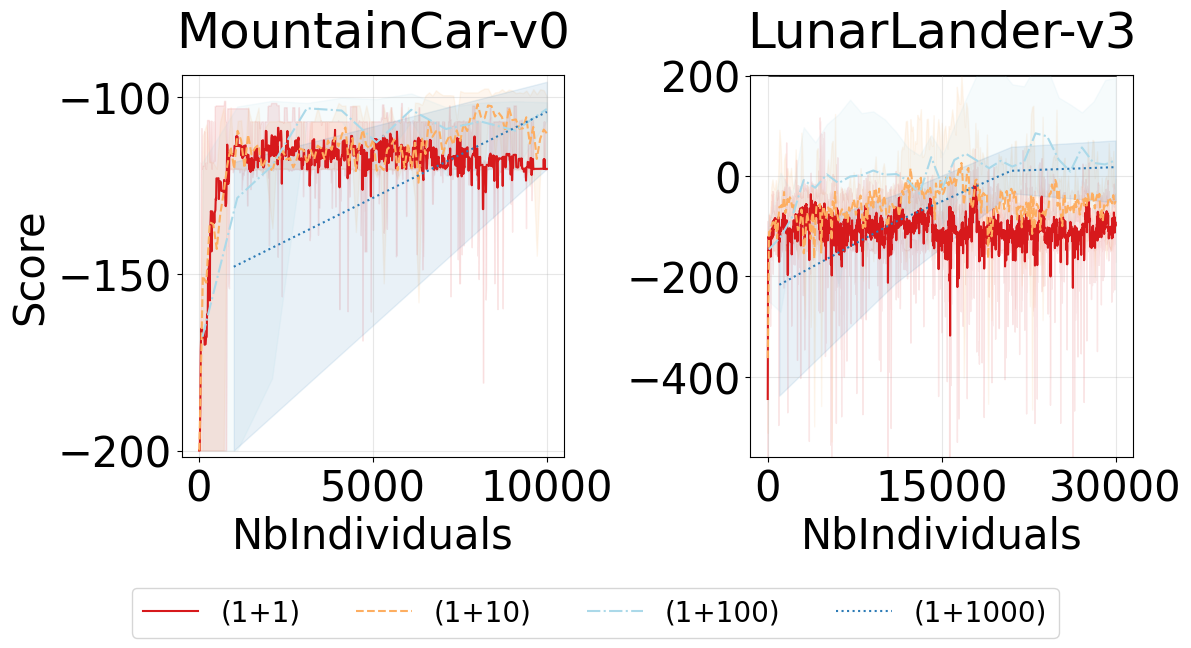

In [ ]:
configs = [
    {
        "label": f"(1+1)",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":1, "lambda":1}
    }, 
    {
        "label": f"(1+10)",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":1, "lambda":10}
    }, 
    {
        "label": f"(1+100)",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":1, "lambda":100, "replacement":"(mu+lambda)"}
    }, 
    {
        "label": f"(1+1000)",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":1, "lambda":1000}
    }, 
]

plot_configurations(
    results=results,
    env_name=["MountainCar-v0", "LunarLander-v3"],
    configs=configs,
    ylabel="Score",
    xlabel="NbIndividuals",
    input="index_individual",
    n_col_legend=5,
    save_file_path="notebook_figures/chapter2/onePlusLambdaStudy.pdf",
    title=["MountainCar-v0", "LunarLander-v3"],
    y_margin=0.2,
    x_ticks = [[0,5000,10000],[0,15000,30000]]
)

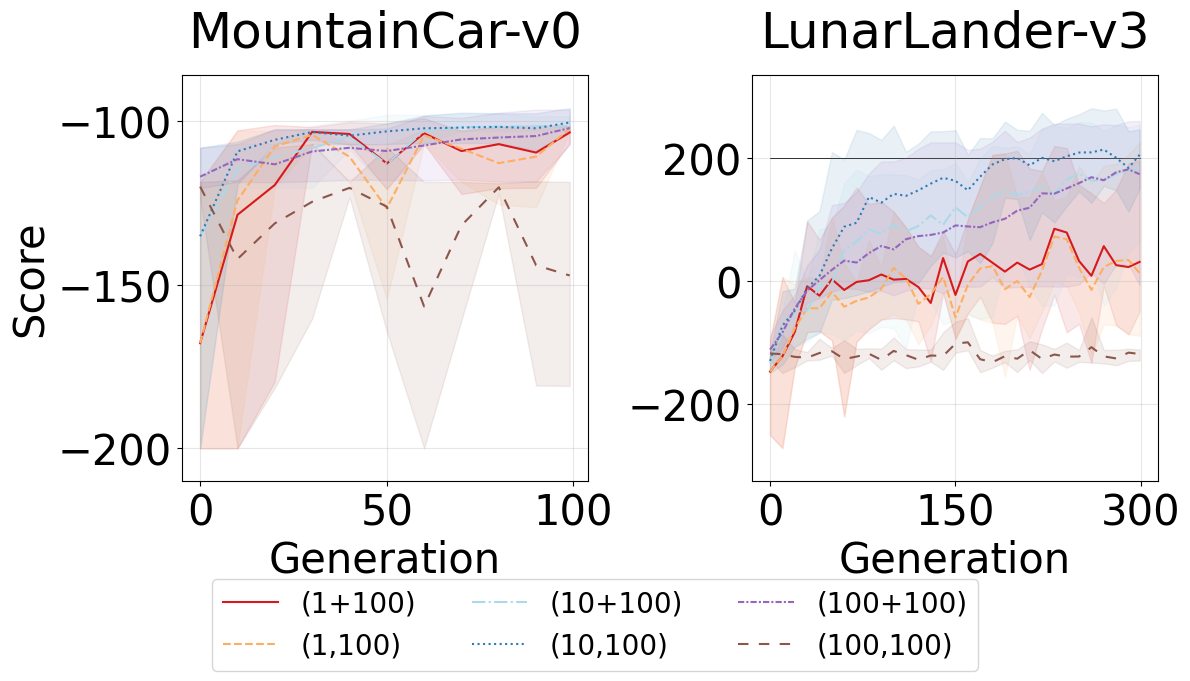

In [ ]:
configs = [
    {
        "label": f"(1+100)",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":1, "lambda":100, "replacement":"(mu+lambda)"}
    }, 
    {
        "label": f"(1,100)",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":1, "lambda":100, "replacement":"(mu,lambda)"}
    }, 
    {
        "label": f"(10+100)",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":10, "lambda":100, "replacement":"(mu+lambda)"}
    }, 
    {
        "label": f"(10,100)",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":10, "lambda":100, "replacement":"(mu,lambda)"}
    }, 
    {
        "label": f"(100+100)",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":100, "lambda":100, "replacement":"(mu+lambda)", "selection":"random", "reproduction":"replication"}
    }, 
    {
        "label": f"(100,100)",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":100, "lambda":100, "replacement":"(mu,lambda)"}
    }, 
]

plot_configurations(
    results=results,
    env_name=["MountainCar-v0", "LunarLander-v3"],
    configs=configs,
    ylabel="Score",
    xlabel="Generation",
    input="index_generation",
    n_col_legend=3,
    save_file_path="notebook_figures/chapter2/muPlusLambdaStudy.pdf",
    title=["MountainCar-v0", "LunarLander-v3"],
    y_margin=1.5,
    x_ticks = [[0,50,100],[0,150,300]]
)

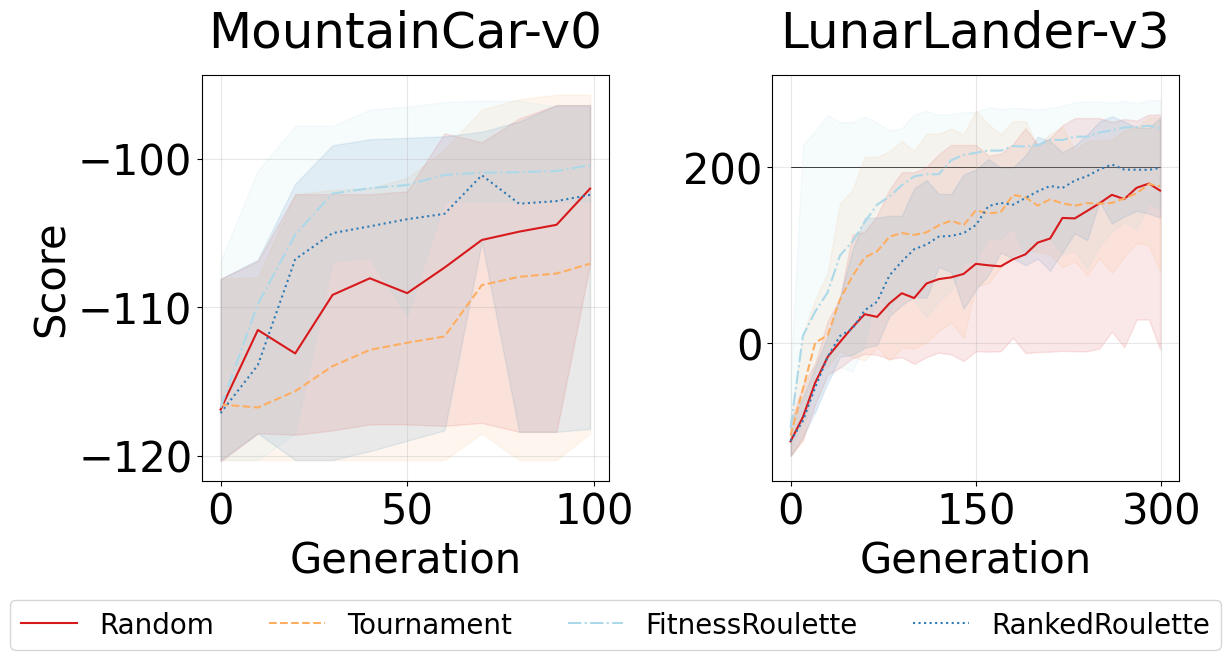

In [ ]:
configs = [
    {
        "label": f"Random",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":100, "lambda":100, "selection":"random", "replacement":"(mu+lambda)"}
    }, 
    {
        "label": f"Tournament",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":100, "lambda":100, "selection":"tournament", "reproduction":"replication"}
    }, 
    {
        "label": f"FitnessRoulette",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":100, "lambda":100, "selection":"fitnessRoulette"}
    }, 
    {
        "label": f"RankedRoulette",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":100, "lambda":100, "selection":"rankedRoulette"}
    }, 
]

plot_configurations(
    results=results,
    env_name=["MountainCar-v0", "LunarLander-v3"],
    configs=configs,
    ylabel="Score",
    xlabel="Generation",
    input="index_generation",
    n_col_legend=5,
    save_file_path="notebook_figures/chapter2/selectionStudy.pdf",
    title=["MountainCar-v0", "LunarLander-v3"],
    y_margin=0.8,
    x_ticks = [[0,50,100],[0,150,300]]
)

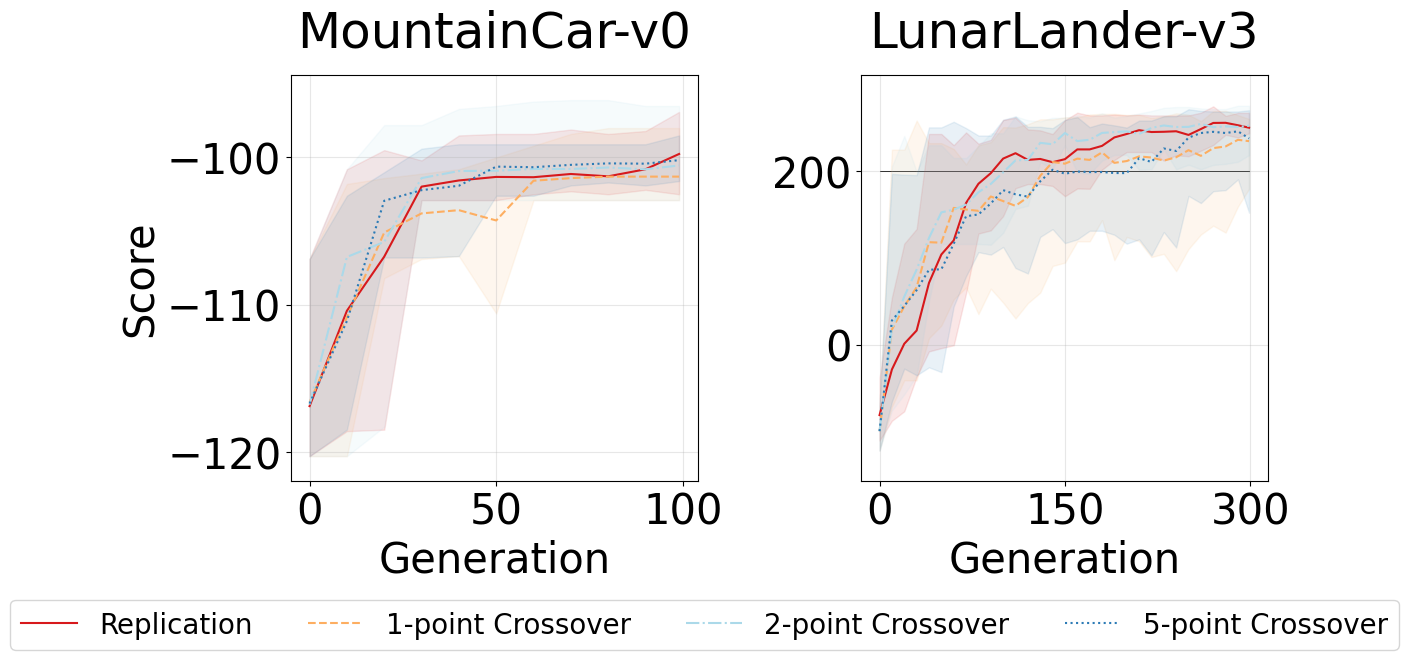

In [ ]:
configs = [
    {
        "label": f"Replication",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":100, "lambda":100, "selection":"fitnessRoulette", "replacement":"(mu+lambda)", "reproduction":"replication"}
    }, 
    {
        "label": f"1-point Crossover",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":100, "lambda":100, "selection":"fitnessRoulette", "replacement":"(mu+lambda)", "reproduction":"crossover", "NbPointCross":1}
    }, 
    {
        "label": f"2-point Crossover",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":100, "lambda":100, "selection":"fitnessRoulette", "replacement":"(mu+lambda)", "reproduction":"crossover", "NbPointCross":2}
    }, 
    {
        "label": f"5-point Crossover",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":100, "lambda":100, "selection":"fitnessRoulette", "replacement":"(mu+lambda)", "reproduction":"crossover", "NbPointCross":5}
    }, 
]

plot_configurations(
    results=results,
    env_name=["MountainCar-v0", "LunarLander-v3"],
    configs=configs,
    ylabel="Score",
    xlabel="Generation",
    input="index_generation",
    n_col_legend=5,
    save_file_path="notebook_figures/chapter2/reproductionStudy.pdf",
    title=["MountainCar-v0", "LunarLander-v3"],
    y_margin=1.0,
    x_ticks = [[0,50,100],[0,150,300]]
)

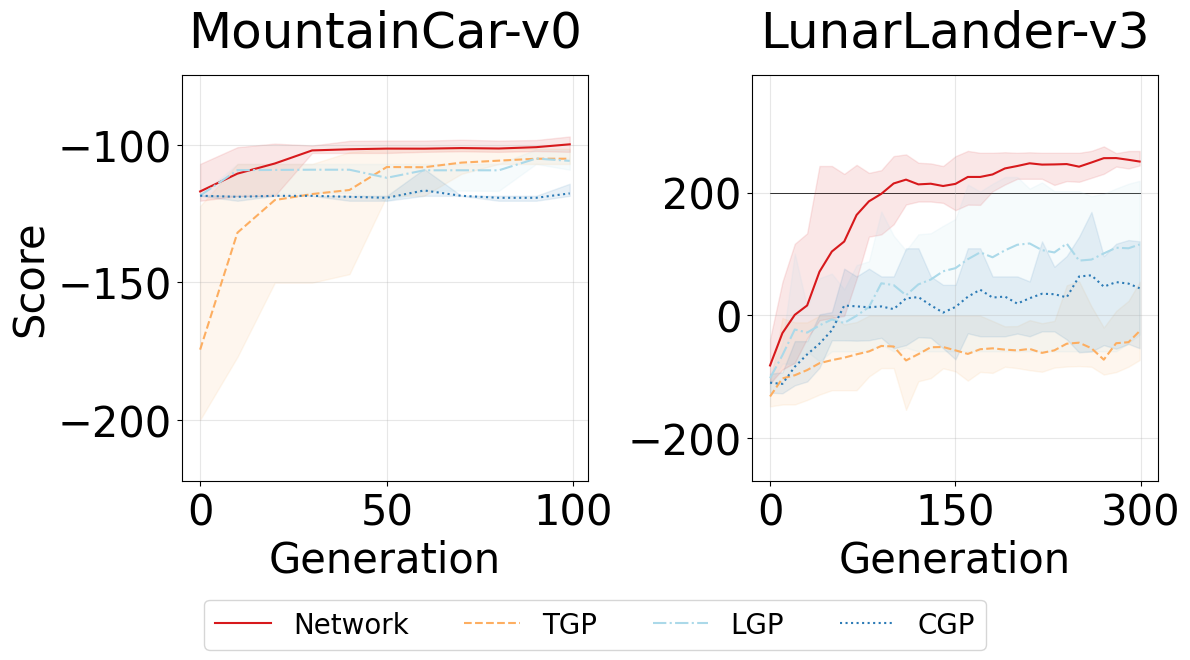

In [ ]:
configs = [
    {
        "label": f"Network",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":100, "lambda":100, "selection":"fitnessRoulette", "replacement":"(mu+lambda)", "reproduction":"replication"}
    },
    {
        "label": f"TGP",
        "rep_name": "TGP",
        "evolution": {"mu":100, "lambda":100, "selection":"fitnessRoulette", "replacement":"(mu+lambda)", "reproduction":"replication"}
    },
    {
        "label": f"LGP",
        "rep_name": "LGP",
        "evolution": {"mu":100, "lambda":100, "selection":"fitnessRoulette", "replacement":"(mu+lambda)", "reproduction":"replication"}
    },
    {
        "label": f"CGP",
        "rep_name": "CGP",
        "evolution": {"mu":100, "lambda":100, "selection":"fitnessRoulette", "replacement":"(mu+lambda)", "reproduction":"replication"}
    },
]

plot_configurations(
    results=results,
    env_name=["MountainCar-v0", "LunarLander-v3"],
    configs=configs,
    ylabel="Score",
    xlabel="Generation",
    input="index_generation",
    n_col_legend=5,
    save_file_path="notebook_figures/chapter2/gp-replicationStudy.pdf",
    title=["MountainCar-v0", "LunarLander-v3"],
    y_margin=3,
    x_ticks = [[0,50,100],[0,150,300]]
)

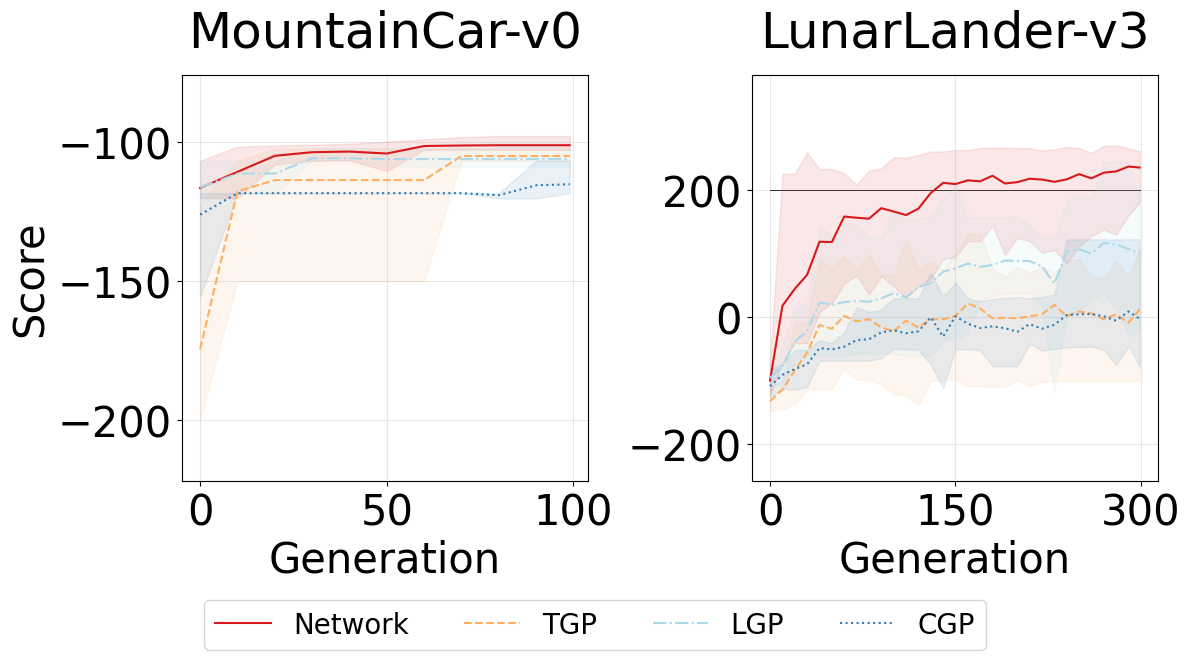

In [ ]:
configs = [
    {
        "label": f"Network",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":100, "lambda":100, "selection":"fitnessRoulette", "replacement":"(mu+lambda)", "reproduction":"crossover", "NbPointCross":1}
    },
    {
        "label": f"TGP",
        "rep_name": "TGP",
        "evolution": {"mu":100, "lambda":100, "selection":"fitnessRoulette", "replacement":"(mu+lambda)", "reproduction":"crossover", "NbPointCross":1}
    },
    {
        "label": f"LGP",
        "rep_name": "LGP",
        "evolution": {"mu":100, "lambda":100, "selection":"fitnessRoulette", "replacement":"(mu+lambda)", "reproduction":"crossover", "NbPointCross":1}
    },
    {
        "label": f"CGP",
        "rep_name": "CGP",
        "evolution": {"mu":100, "lambda":100, "selection":"fitnessRoulette", "replacement":"(mu+lambda)", "reproduction":"crossover", "NbPointCross":1}
    },
]

plot_configurations(
    results=results,
    env_name=["MountainCar-v0", "LunarLander-v3"],
    configs=configs,
    ylabel="Score",
    xlabel="Generation",
    input="index_generation",
    n_col_legend=5,
    save_file_path="notebook_figures/chapter2/gp-crossoverStudy.pdf",
    title=["MountainCar-v0", "LunarLander-v3"],
    y_margin=3,
    x_ticks = [[0,50,100],[0,150,300]]
)

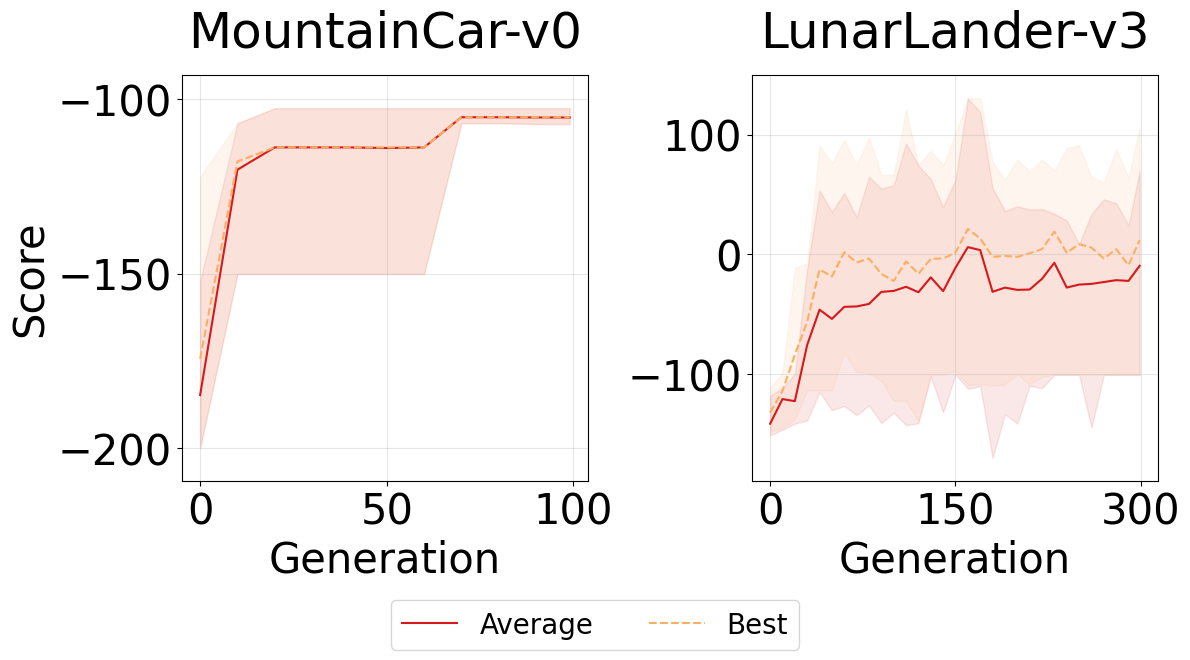

In [ ]:
configs = [
    {
        "label": f"Average",
        "rep_name": "TGP",
        "evolution": {"mu":100, "lambda":100, "selection":"fitnessRoulette", "replacement":"(mu+lambda)", "reproduction":"crossover", "NbPointCross":1},
        "metric":"avg_valid_score"
    },
    {
        "label": f"Best",
        "rep_name": "TGP",
        "evolution": {"mu":100, "lambda":100, "selection":"fitnessRoulette", "replacement":"(mu+lambda)", "reproduction":"crossover", "NbPointCross":1},
        "metric":"max_valid_score"
    },
]

plot_configurations(
    results=results,
    env_name=["MountainCar-v0", "LunarLander-v3"],
    configs=configs,
    ylabel="Score",
    xlabel="Generation",
    input="index_generation",
    n_col_legend=5,
    save_file_path="notebook_figures/chapter2/tgp_diversity.pdf",
    title=["MountainCar-v0", "LunarLander-v3"],
    y_margin=1.2,
    x_ticks = [[0,50,100],[0,150,300]]
)

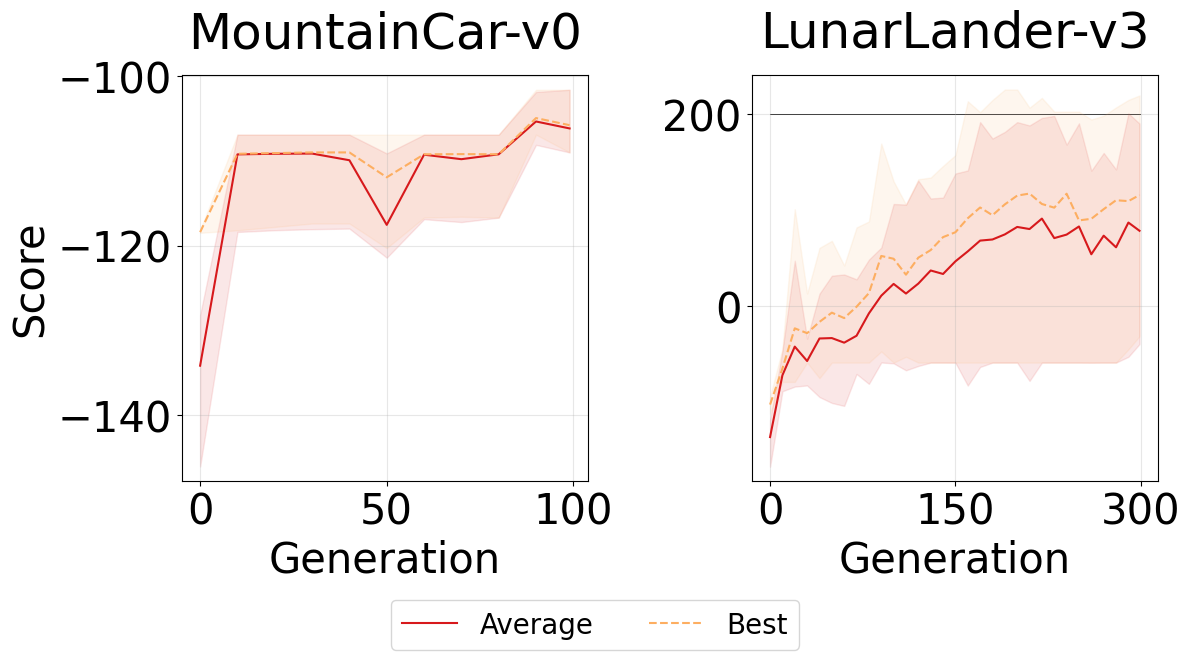

In [ ]:
configs = [
    {
        "label": f"Average",
        "rep_name": "LGP",
        "evolution": {"mu":100, "lambda":100, "selection":"fitnessRoulette", "replacement":"(mu+lambda)", "reproduction":"replication"},
        "metric":"avg_valid_score"
    },
    {
        "label": f"Best",
        "rep_name": "LGP",
        "evolution": {"mu":100, "lambda":100, "selection":"fitnessRoulette", "replacement":"(mu+lambda)", "reproduction":"replication"},
        "metric":"max_valid_score"
    },
]

plot_configurations(
    results=results,
    env_name=["MountainCar-v0", "LunarLander-v3"],
    configs=configs,
    ylabel="Score",
    xlabel="Generation",
    input="index_generation",
    n_col_legend=5,
    save_file_path="notebook_figures/chapter2/lgp_diversity.pdf",
    title=["MountainCar-v0", "LunarLander-v3"],
    y_margin=0.6,
    x_ticks = [[0,50,100],[0,150,300]]
)

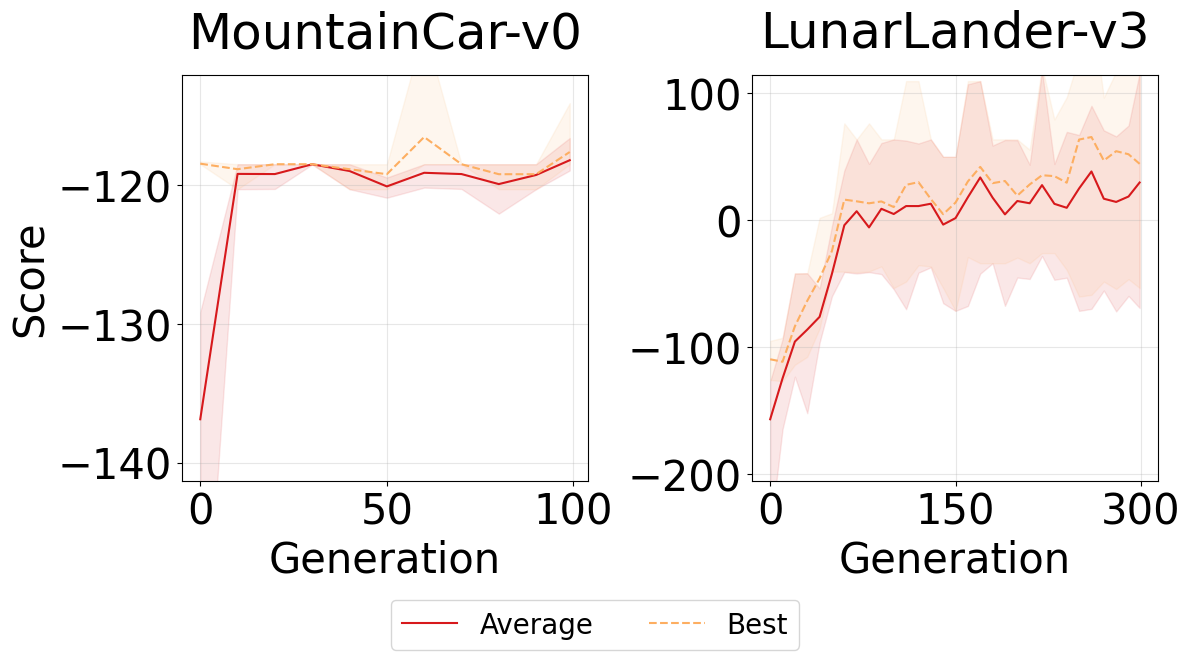

In [ ]:
configs = [
    {
        "label": f"Average",
        "rep_name": "CGP",
        "evolution": {"mu":100, "lambda":100, "selection":"fitnessRoulette", "replacement":"(mu+lambda)", "reproduction":"replication"},
        "metric":"avg_valid_score"
    },
    {
        "label": f"Best",
        "rep_name": "CGP",
        "evolution": {"mu":100, "lambda":100, "selection":"fitnessRoulette", "replacement":"(mu+lambda)", "reproduction":"replication"},
        "metric":"max_valid_score"
    },
]

plot_configurations(
    results=results,
    env_name=["MountainCar-v0", "LunarLander-v3"],
    configs=configs,
    ylabel="Score",
    xlabel="Generation",
    input="index_generation",
    n_col_legend=5,
    save_file_path="notebook_figures/chapter2/cgp_diversity.pdf",
    title=["MountainCar-v0", "LunarLander-v3"],
    y_margin=0.2,
    x_ticks = [[0,50,100],[0,150,300]]
)

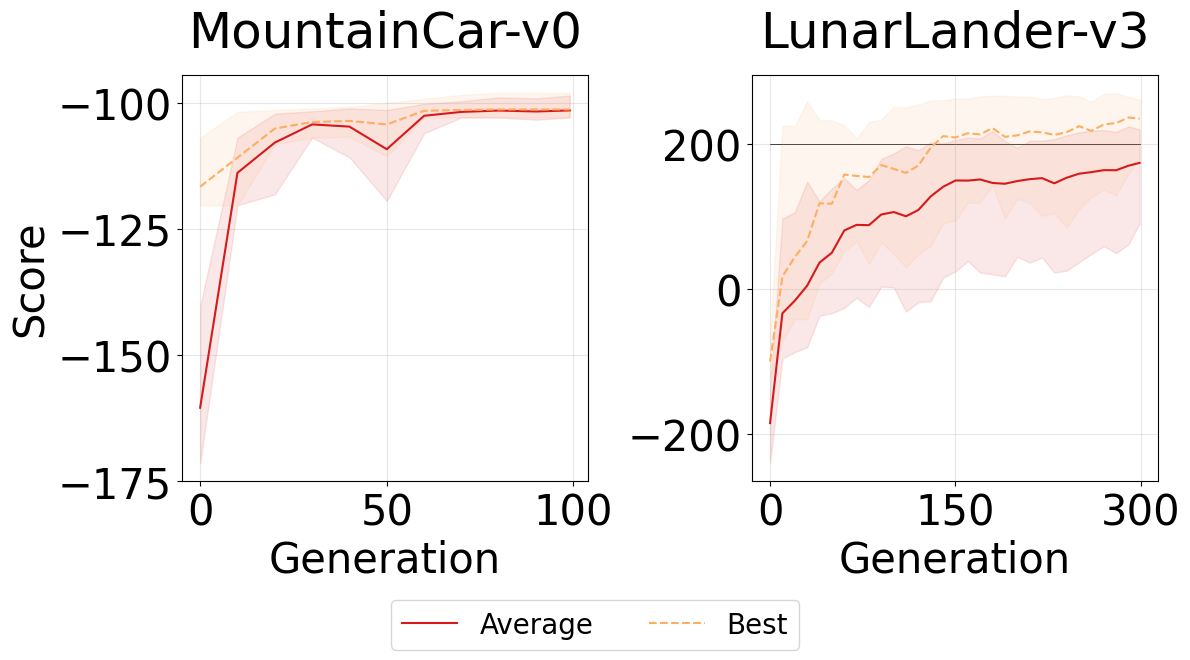

In [ ]:
configs = [
    {
        "label": f"Average",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":100, "lambda":100, "selection":"fitnessRoulette", "replacement":"(mu+lambda)", "reproduction":"crossover", "NbPointCross":1},
        "metric":"avg_valid_score"
    },
    {
        "label": f"Best",
        "rep_name": "Network",
        "rep_params": {"hidden_layer": 1, "hidden_size": 64},
        "evolution": {"mu":100, "lambda":100, "selection":"fitnessRoulette", "replacement":"(mu+lambda)", "reproduction":"crossover", "NbPointCross":1},
        "metric":"max_valid_score"
    },
]

plot_configurations(
    results=results,
    env_name=["MountainCar-v0", "LunarLander-v3"],
    configs=configs,
    ylabel="Score",
    xlabel="Generation",
    input="index_generation",
    n_col_legend=5,
    save_file_path="notebook_figures/chapter2/network_diversity.pdf",
    title=["MountainCar-v0", "LunarLander-v3"],
    y_margin=0.6,
    x_ticks = [[0,50,100],[0,150,300]]
)

Print best individuals

In [ ]:
for i, r in enumerate(results):
    if "GP" in r["rep_name"] and r["evolution"]["selection"] == "fitnessRoulette":
        if r["env_name"] == "MountainCar-v0":
            print(i, "MountainCar", r["rep_name"], r["logs"]["max_valid_score"][99], r["evolution"]["reproduction"])
        if r["env_name"] == "LunarLander-v3":
            print(i, "LunarLander", r["rep_name"], r["logs"]["max_valid_score"][299], r["evolution"]["reproduction"])

150 LunarLander TGP 14.823780314526482 crossover
151 LunarLander TGP 50.61207963210695 crossover
152 LunarLander TGP -100.82933730434131 crossover
153 LunarLander TGP -11.946843273572142 crossover
154 LunarLander TGP 106.10030119104837 crossover
155 LunarLander TGP -65.38161627146329 replication
156 LunarLander TGP 24.861718557045492 replication
157 LunarLander TGP -69.14365818177438 replication
158 LunarLander TGP -72.60587685097202 replication
159 LunarLander TGP 54.641954030257956 replication
160 LunarLander LGP 154.9069619046071 crossover
161 LunarLander LGP 66.52565352552622 crossover
162 LunarLander LGP -23.584977134219155 crossover
163 LunarLander LGP 186.37432114975874 crossover
164 LunarLander LGP 119.1083674031443 crossover
165 LunarLander LGP 219.09840483640127 replication
166 LunarLander LGP 188.91734646733678 replication
167 LunarLander LGP 14.523571650269995 replication
168 LunarLander LGP -31.20049283434654 replication
169 LunarLander LGP 186.3973796769165 replication
17

In [ ]:
results[287]["best"].print(INSTRUCTION_NAMES)

R[6] = +(S[0], R[1])
R[5] = /(S[0], S[0])
R[2] = -(R[3], R[0])
R[1] = log(S[0], R[2])
R[3] = +(S[1], R[5])
R[2] = +(S[0], R[3])
R[5] = +(S[1], R[2])
R[4] = +(R[6], R[5])
R[0] = +(R[3], R[4])
R[2] = +(R[0], S[1])
R[2] = /(R[2], S[1])


In [ ]:
results[290]["best"].print(INSTRUCTION_NAMES)

Layer 0
N[0,1] = +(S[1], S[1])
N[0,2] = *(S[0], S[0])
N[0,3] = -(S[0], S[1])
Layer 1
N[1,2] = max(N[0,3], S[0])
N[1,4] = /(N[0,2], S[0])
Layer 2
N[2,1] = +(N[0,1], N[1,4])
OUTPUT[0] = N[0,3]
OUTPUT[1] = N[1,2]
OUTPUT[2] = N[2,1]


In [ ]:
results[259]["best"].print(INSTRUCTION_NAMES)

R[0] = +(S[4], S[3])
R[4] = max(S[7], S[4])
R[1] = -(S[3], R[4])
R[7] = log(R[1], S[2])
R[4] = -(S[0], S[4])
R[1] = log(R[6], R[1])
R[0] = +(R[0], S[7])
R[6] = /(R[2], R[2])
R[3] = max(S[4], R[1])
R[1] = +(R[4], R[4])
R[2] = +(R[7], R[6])
